In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_reg_file(file_path):
    """
    Reads a .reg file, skips comments, and extracts columns into NumPy arrays.
    """
    wavelengths = []
    fluxes = []
    fitted_fluxes = []
    errors = []

    with open(file_path, 'r') as file:
        for line in file:
            # Skip comments
            if line.startswith('#'):
                continue
            
            # Split the line into columns
            parts = line.split()
            if len(parts) >= 4:  # Ensure we have enough columns
                wavelengths.append(float(parts[0]))
                fluxes.append(float(parts[1]))
                fitted_fluxes.append(float(parts[2]))
                errors.append(float(parts[3]))
    
    return np.array(wavelengths), np.array(fluxes), np.array(fitted_fluxes), np.array(errors)

# The fits and parameters

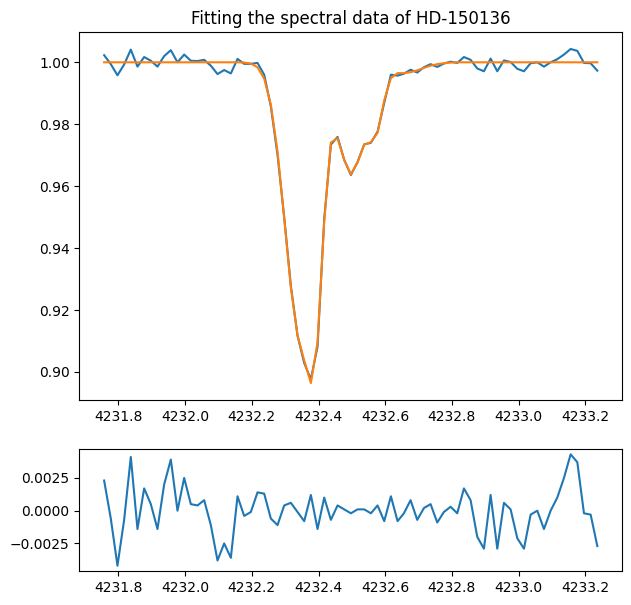

number of parameters: 12
Chi-squared: 109.63775510204016
Reduced Chi-squared: 1.7402818270165106
BIC: 161.44761246447587
AIC: 133.63775510204016


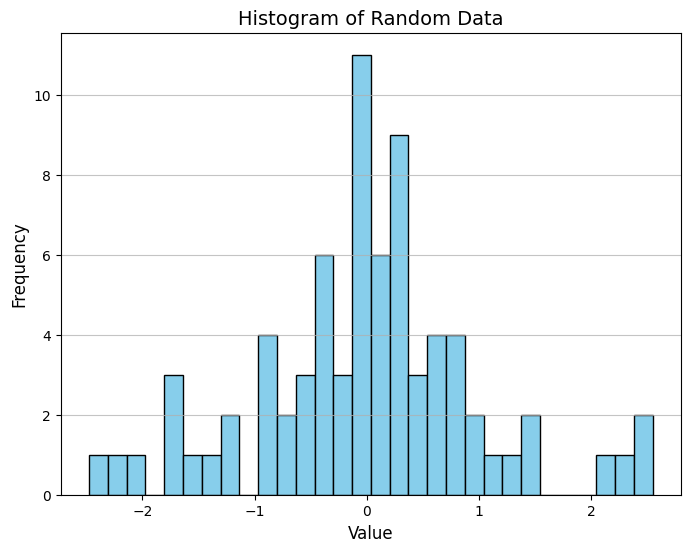

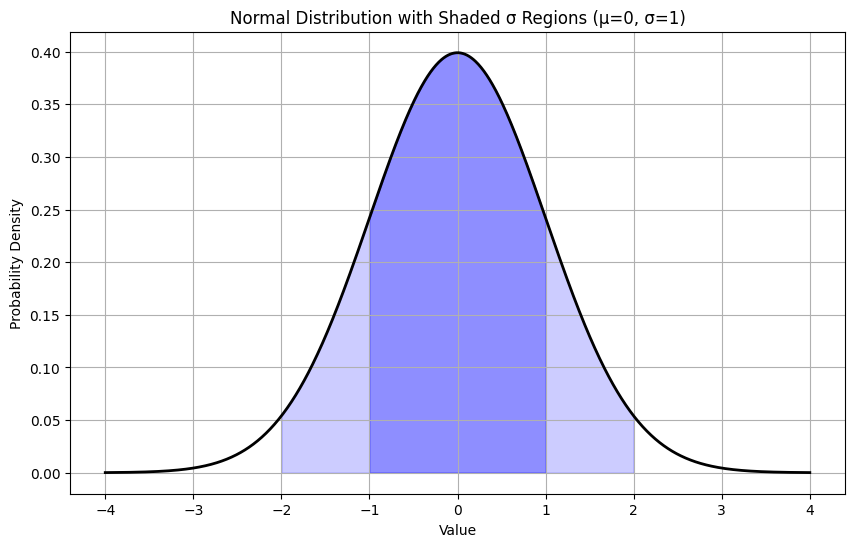

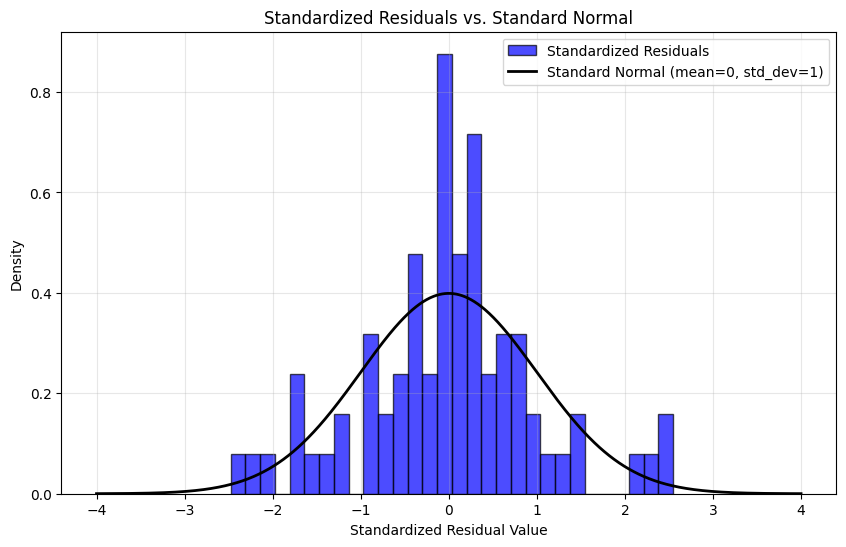

K-S statistic: 0.0935
P-value: 0.4984
Fail to reject null hypothesis - residuals appear normally distributed


In [2]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 150136_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-150136')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  

# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0014  # Assuming a standard deviation for the error
num_params = 12  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

Residuals = fluxes - fitted_fluxes

# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)

# Add grid lines
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()






from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)

# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)

plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()







# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)

# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')

x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')

plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




import numpy as np
from scipy import stats

# # Assuming 'residuals' contains your residual values
# # residuals = ... (your data here)

# # Standardize the residuals (subtract mean, divide by std)
# std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

# Perform K-S test against standard normal distribution
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')

print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("Reject null hypothesis - residuals do not appear normally distributed")





Model A: D=0.017, p=0.920
Model B: D=0.053, p=0.008
Models A vs. B: D=0.065, p=0.029


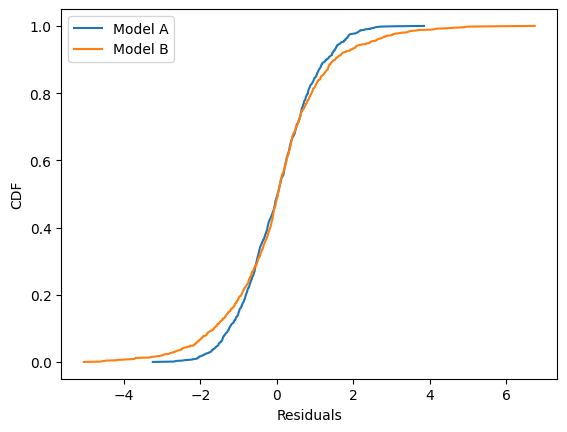

In [3]:
import numpy as np
from scipy.stats import kstest, ks_2samp, norm
import matplotlib.pyplot as plt

# Simulate residuals for two models
np.random.seed(42)
r_A = np.random.normal(0, 1, 1000)  # Model A residuals (close to Gaussian)
r_B = np.random.laplace(0, 1, 1000)  # Model B residuals (non-Gaussian)

# (1) Test against N(0,1)
D_A, p_A = kstest(r_A, 'norm')  # Expect low D, high p
D_B, p_B = kstest(r_B, 'norm')  # Expect high D, low p
print(f"Model A: D={D_A:.3f}, p={p_A:.3f}")  # Better fit to Gaussian
print(f"Model B: D={D_B:.3f}, p={p_B:.3f}")

# (2) Compare residuals directly
D_AB, p_AB = ks_2samp(r_A, r_B)
print(f"Models A vs. B: D={D_AB:.3f}, p={p_AB:.3f}")  # Significant difference

# (3) Plot CDFs
plt.figure()
plt.plot(np.sort(r_A), np.linspace(0, 1, len(r_A)), label='Model A')
plt.plot(np.sort(r_B), np.linspace(0, 1, len(r_B)), label='Model B')
# plt.plot((np.sort(norm.rvs(0, 1, 1000)), np.linspace(0, 1, 1000)), 'k--', label='N(0,1)')
plt.legend(); plt.xlabel("Residuals"); plt.ylabel("CDF"); plt.show()

In [4]:
from scipy.stats import f

# Model parameters
n = 75  # Number of data points
k1, chi2_1 = 15, 111.39  # Model 1
k2, chi2_2 = 12, 132.78  # Model 2

# F-test calculation
chi2_diff = chi2_2 - chi2_1
df1 = k1 - k2
df2 = n - k1
f_stat = (chi2_diff / df1) / (chi2_1 / df2)
p_value = f.sf(f_stat, df1, df2)

# Print results
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}") # p<0.05 indicates model 1 is preferred

F-statistic: 3.8406
P-value: 0.0139


In [5]:
import numpy as np

# Assuming fluxes and fitted_fluxes are numpy arrays with 75 data points
std_dev = 0.0014  # Standard deviation for the error (constant for all points)
num_params = 12   # Number of parameters in the model (e.g., 4 Voigt profiles with 3 parameters each)
num_data_points = len(fluxes)  # Number of data points (e.g., 75)

# Calculate chi-squared
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)

# Calculate log-likelihood
# For constant std_dev: sum(ln(sigma_i)) = n * ln(std_dev)
# If std_dev varies per data point, replace with: np.sum(np.log(std_dev)) where std_dev is an array
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
print('Number of parameters:', num_params)
print(f"Chi-squared: {chi_squared:.4f}")
print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: {aic:.4f}")
print(f"BIC: {bic:.4f}")

Number of parameters: 12
Chi-squared: 109.6378
Reduced Chi-squared: 1.7403
Log-likelihood: 369.1070
AIC: -714.2139
BIC: -686.4041


In [6]:
from scipy.stats import chi2

# Given chi2 values and degrees of freedom
chi2_model1 = 111.39
chi2_model2 = 132.78
df_diff = 3  # 15 - 12 parameters

# Likelihood ratio test
lambda_LRT = chi2_model2 - chi2_model1
p_value = 1 - chi2.cdf(lambda_LRT, df_diff)

print(f"LRT statistic: {lambda_LRT:.2f}")
print(f"p-value: {p_value:.2e}")  # Output: p-value: 8.86e-05. p<<0.05 strong evidence against simpler model

LRT statistic: 21.39
p-value: 8.74e-05


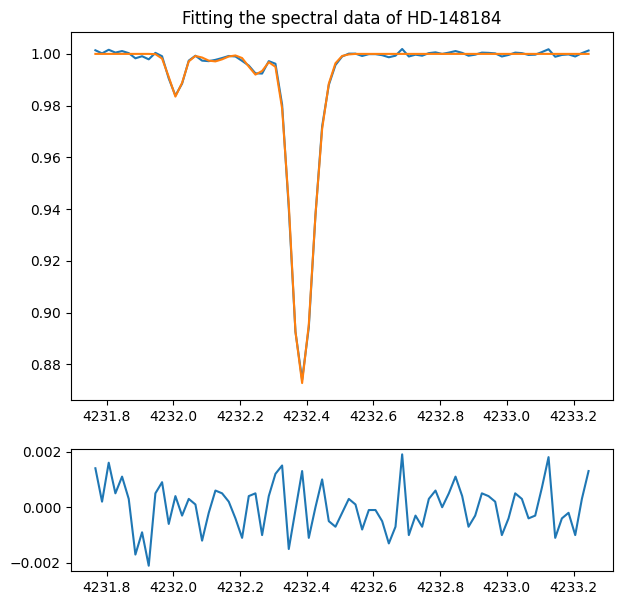

number of parameters: 13
Chi-squared: 26.959183673469546
Reduced Chi-squared: 0.43482554312047655
Log-likelihood: 410.4462
AIC:  -794.8924926999682
BIC:  -764.7651472239962


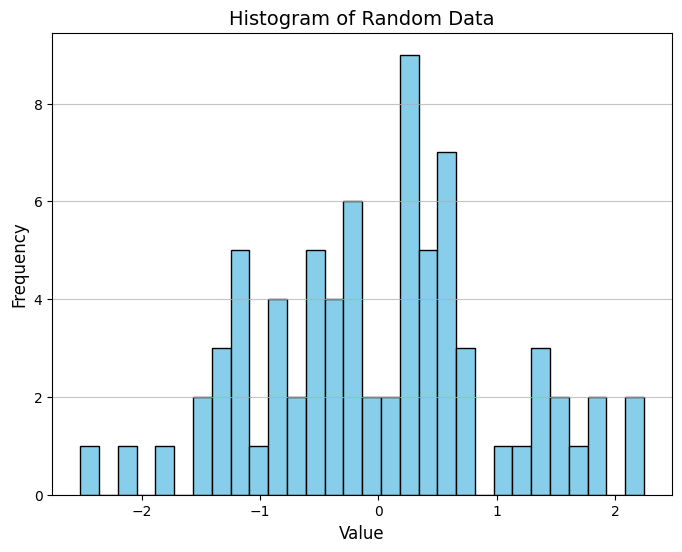

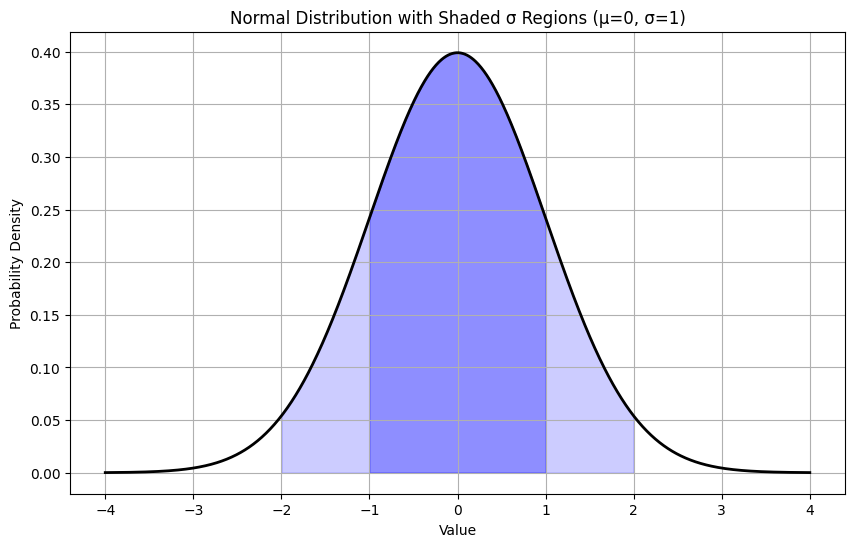

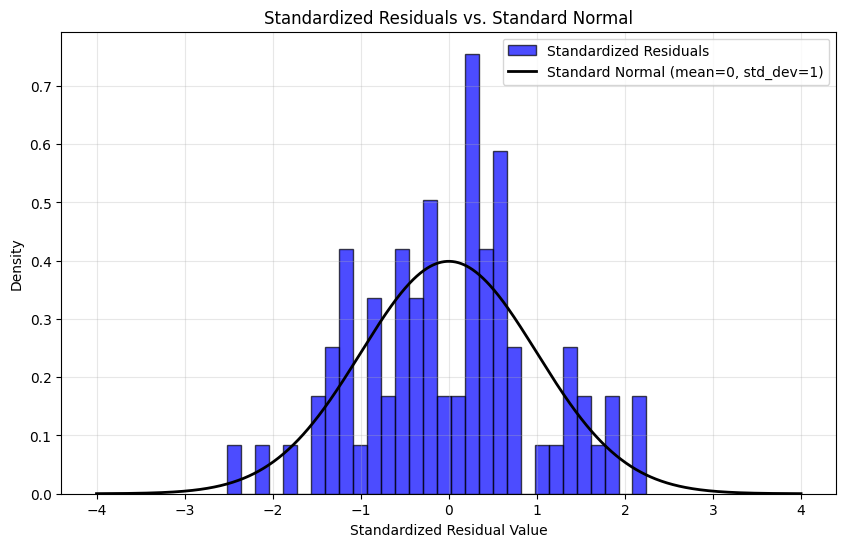

K-S statistic: 0.0821
P-value: 0.6628
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed
F-statistic: 9.9555
P-value: 0.0025 and p<0.05 indicates more complex is preferred
LRT statistic: 0.00
p-value: 1.00e+00 and p<<0.05 strong evidence against simpler model


In [7]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 148184_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-148184')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  

# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0014  # Assuming a standard deviation for the error
num_params = 13  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

    



#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''
# COMPARATIVE STUDY BETWEEN DIFFERENT MODELS




# Perform F test 

from scipy.stats import f
# Model parameters
n = 75  # Number of data points
k1, chi2_1 = 14, 26.96  # Model 1
k2, chi2_2 = 13, 31.36  # Model 2
# F-test calculation
chi2_diff = chi2_2 - chi2_1
df1 = k1 - k2
df2 = n - k1
f_stat = (chi2_diff / df1) / (chi2_1 / df2)
p_value = f.sf(f_stat, df1, df2)
# Print results
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f} and p<0.05 indicates more complex is preferred")




# LRT test

from scipy.stats import chi2
# Given chi2 values and degrees of freedom
chi2_model1 = 31.36
chi2_model2 = 31.36
df_diff = 1  # 13 - 10 parameters
# Likelihood ratio test
lambda_LRT = chi2_model2 - chi2_model1
p_value = 1 - chi2.cdf(lambda_LRT, df_diff)
print(f"LRT statistic: {lambda_LRT:.2f}")
print(f"p-value: {p_value:.2e} and p<<0.05 strong evidence against simpler model")





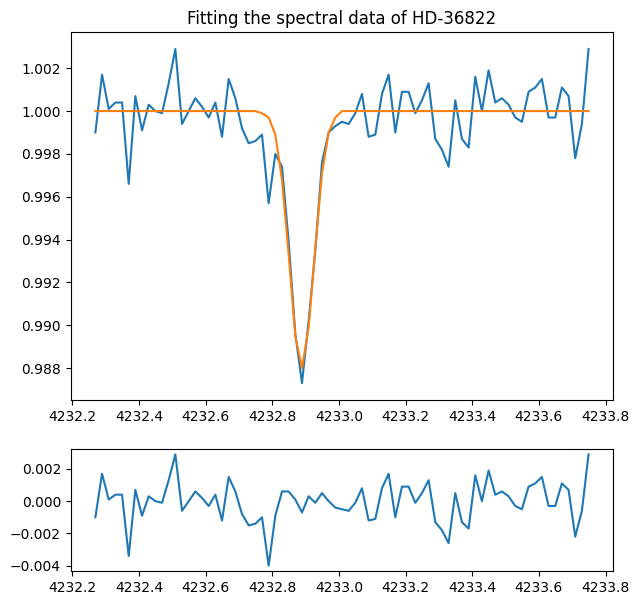

number of parameters: 3
Chi-squared: 77.87499999999905
Reduced Chi-squared: 1.081597222222209
Log-likelihood: 396.5496
AIC:  -787.0992783475275
BIC:  -780.1468140069186


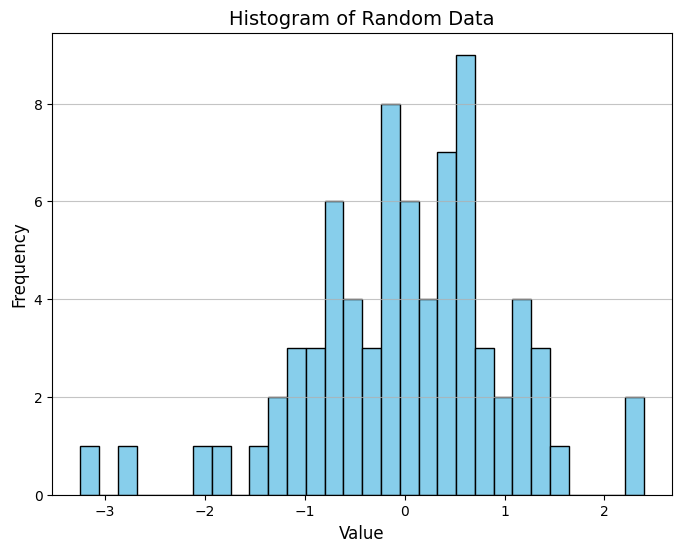

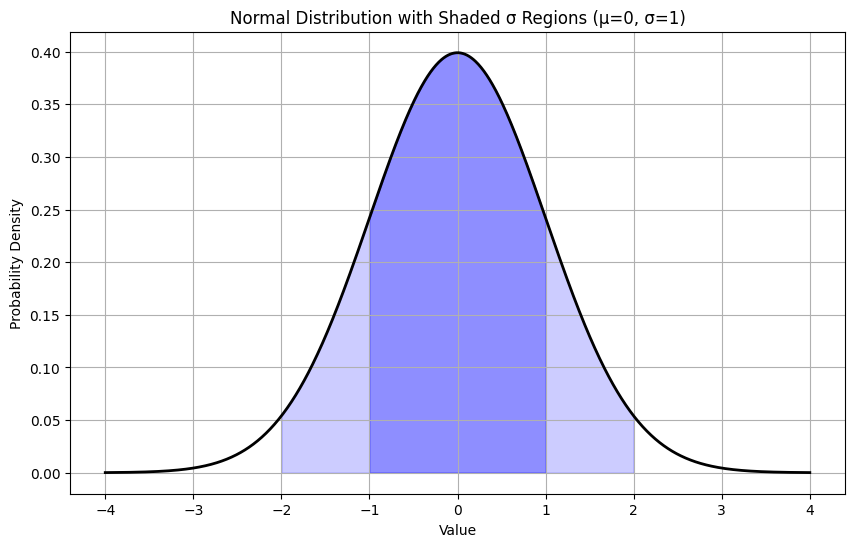

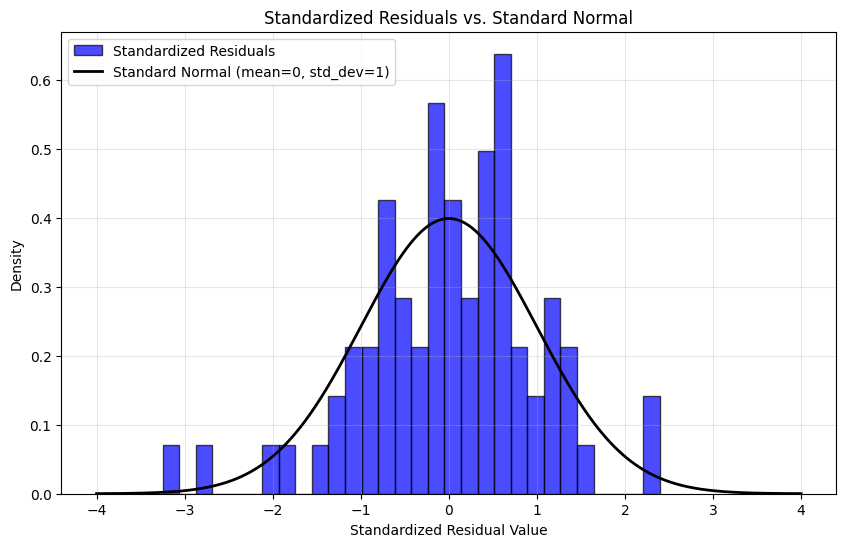

K-S statistic: 0.0770
P-value: 0.7368
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [8]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 36822_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-36822')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  

# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0012  # Assuming a standard deviation for the error
num_params = 3  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

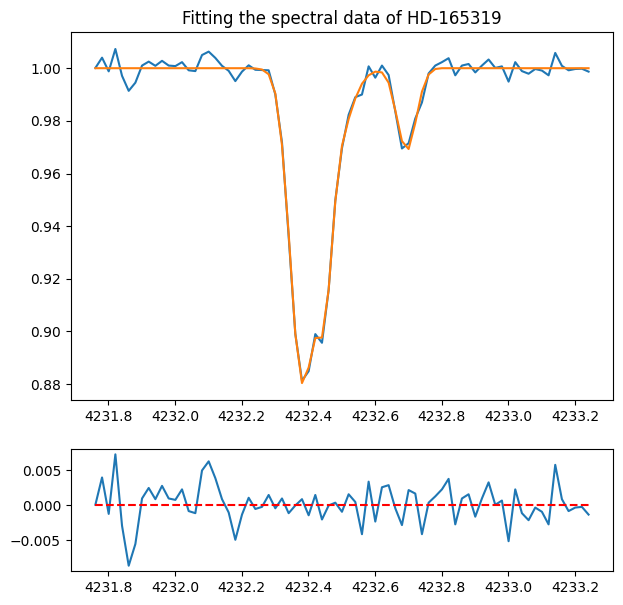

number of parameters: 12
Chi-squared: 112.6322314049582
Reduced Chi-squared: 1.7878131969040985
Log-likelihood: 333.7108
AIC:  -643.4216764070209
BIC:  -615.6118190445851


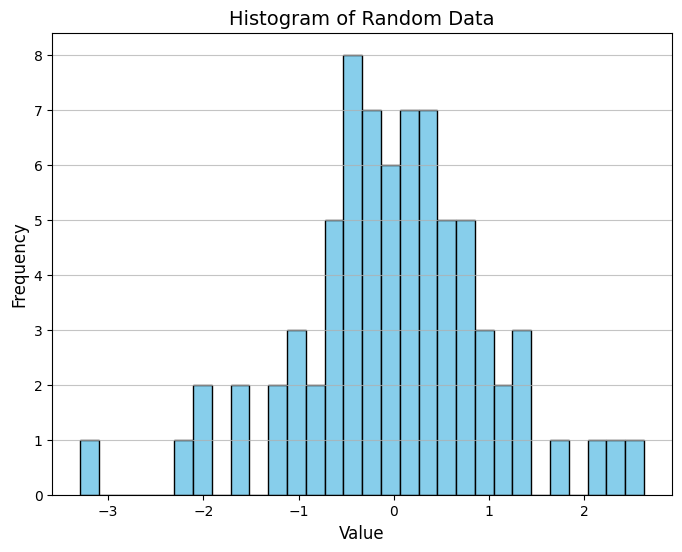

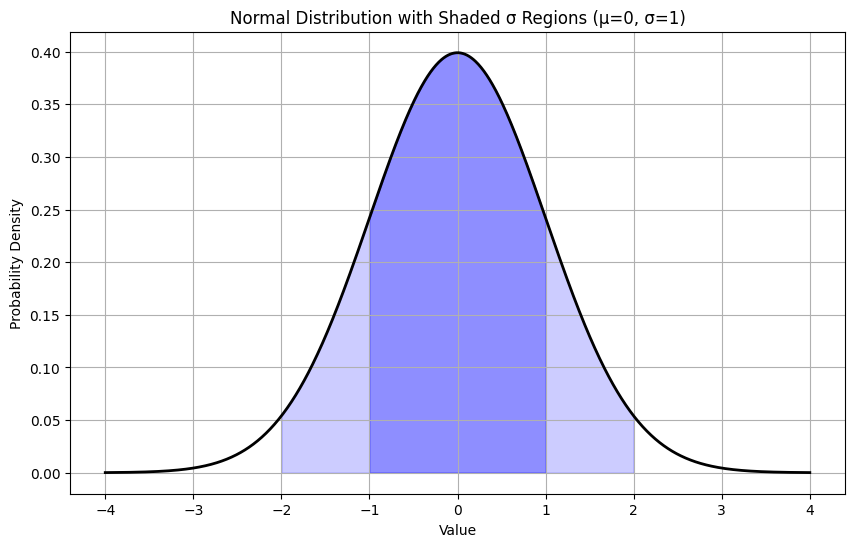

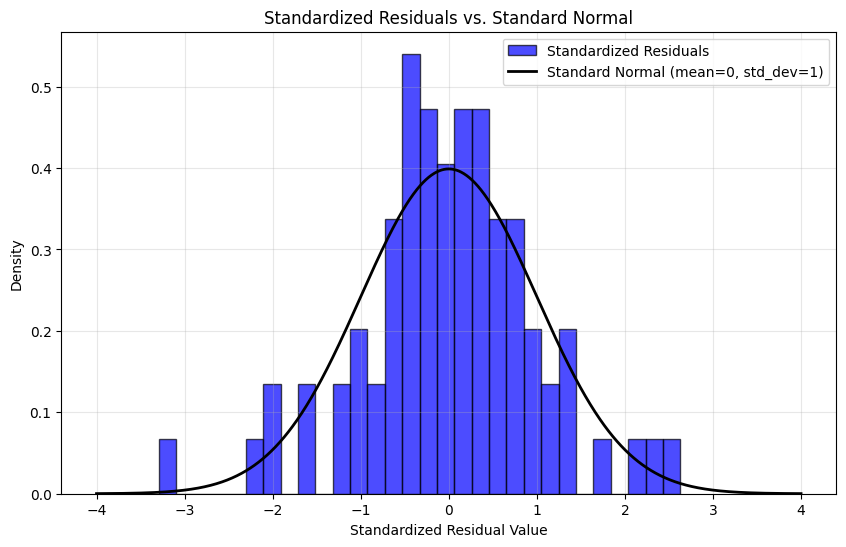

K-S statistic: 0.0840
P-value: 0.6340
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [9]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 165319_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-165319')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0022  # Assuming a standard deviation for the error
num_params = 12  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

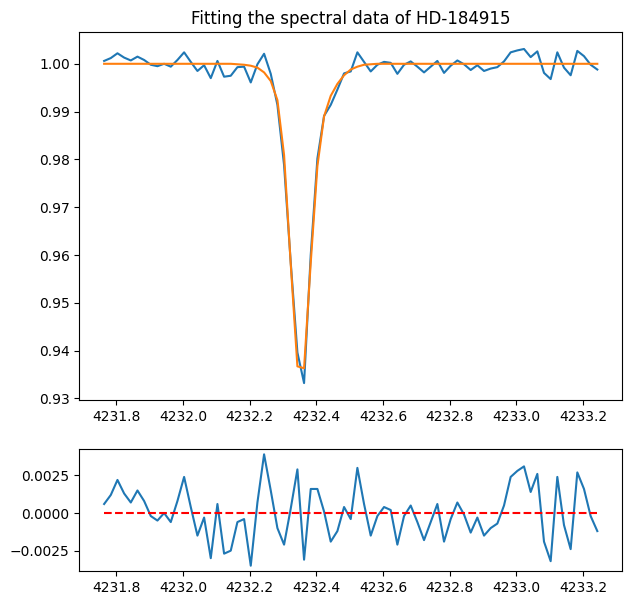

number of parameters: 9
Chi-squared: 326.687499999998
Reduced Chi-squared: 4.949810606060576
Log-likelihood: 302.5533
AIC:  -587.106544563753
BIC:  -566.2491515419263


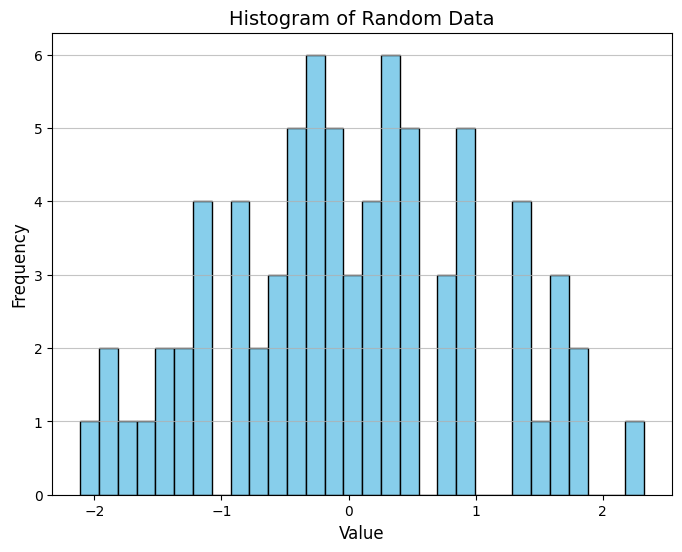

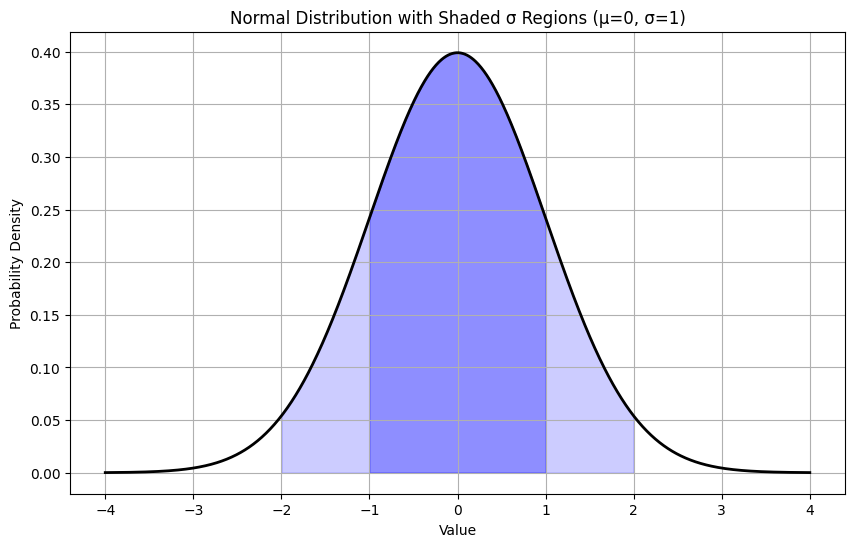

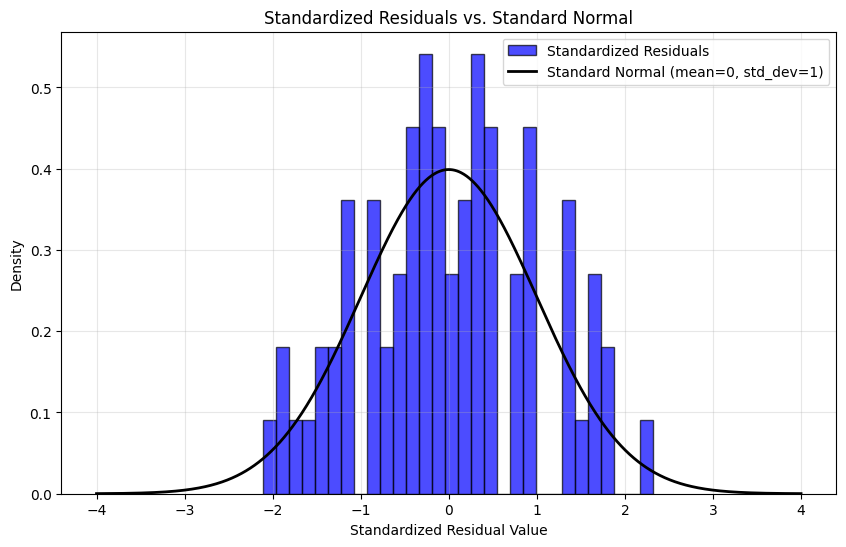

K-S statistic: 0.0671
P-value: 0.8653
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [10]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 184915_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-184915')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0008  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

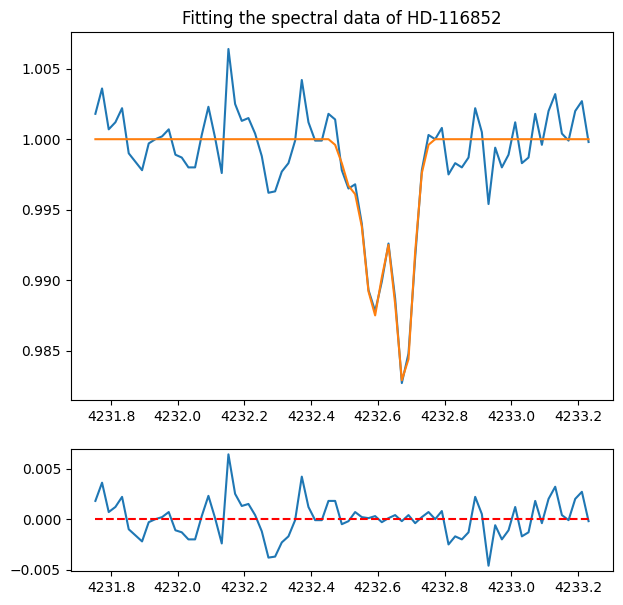

number of parameters: 9
Chi-squared: 98.91015625000013
Reduced Chi-squared: 1.498638731060608
Log-likelihood: 364.4559
AIC:  -710.9118112297592
BIC:  -690.0544182079325


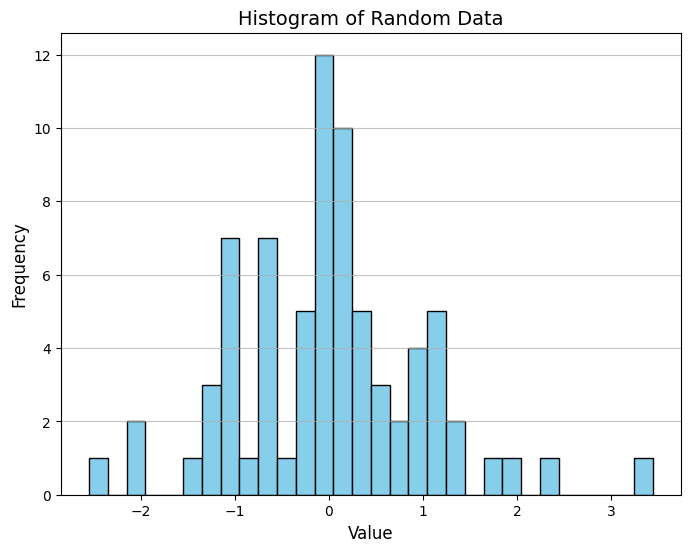

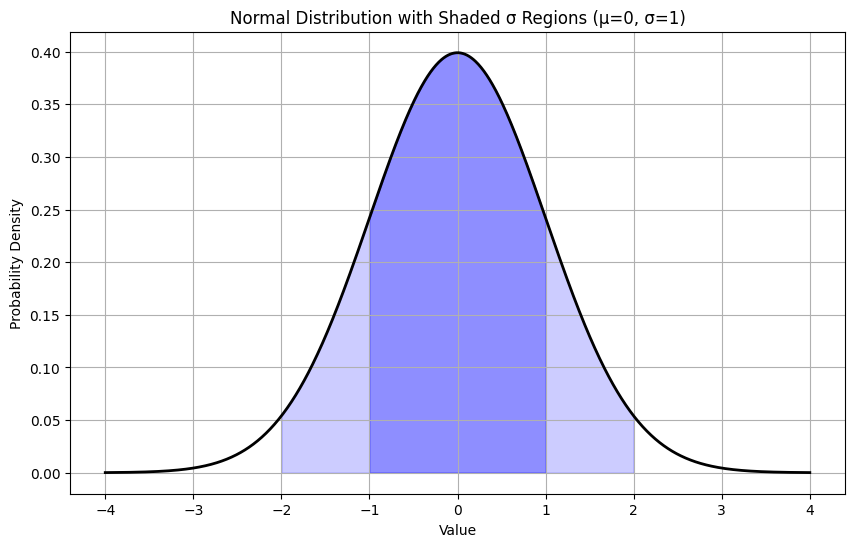

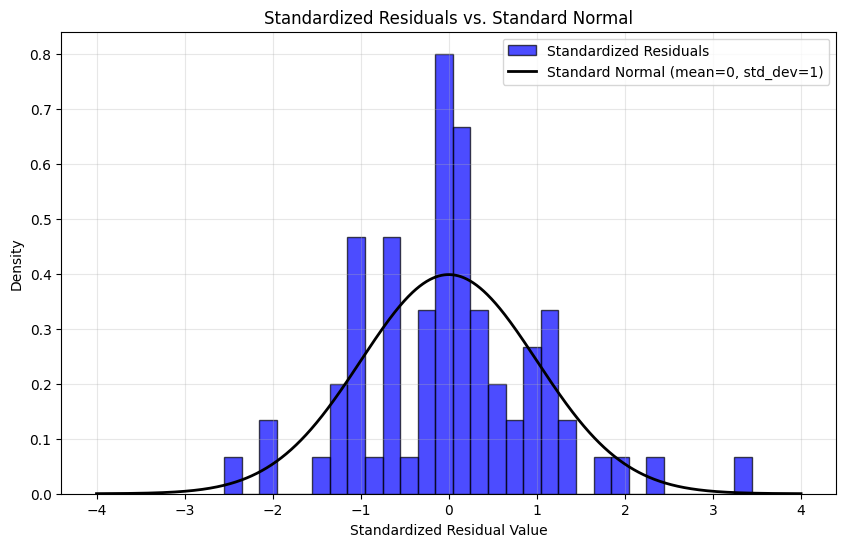

K-S statistic: 0.0880
P-value: 0.5756
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [11]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 116852_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-116852')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0016  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

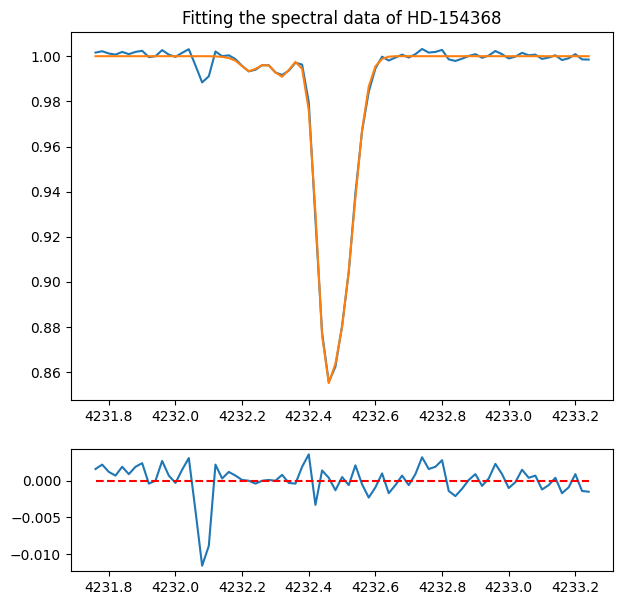

number of parameters: 14
Chi-squared: 384.02000000000135
Reduced Chi-squared: 6.295409836065596
Log-likelihood: 257.1513
AIC:  -486.3025118666184
BIC:  -453.85767827711004


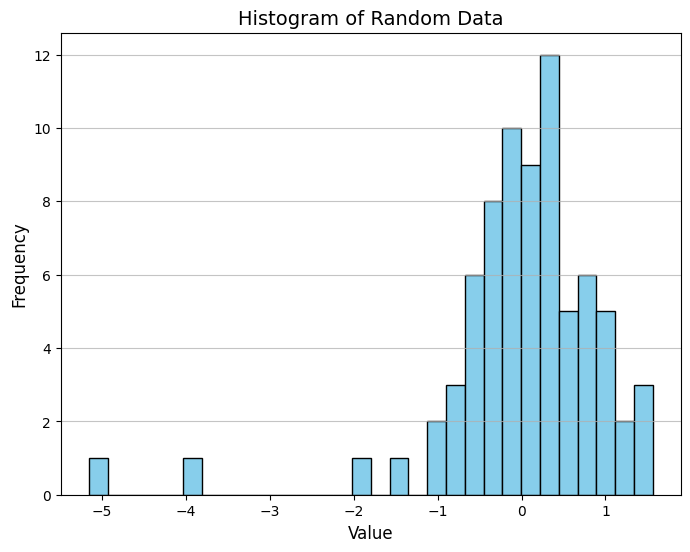

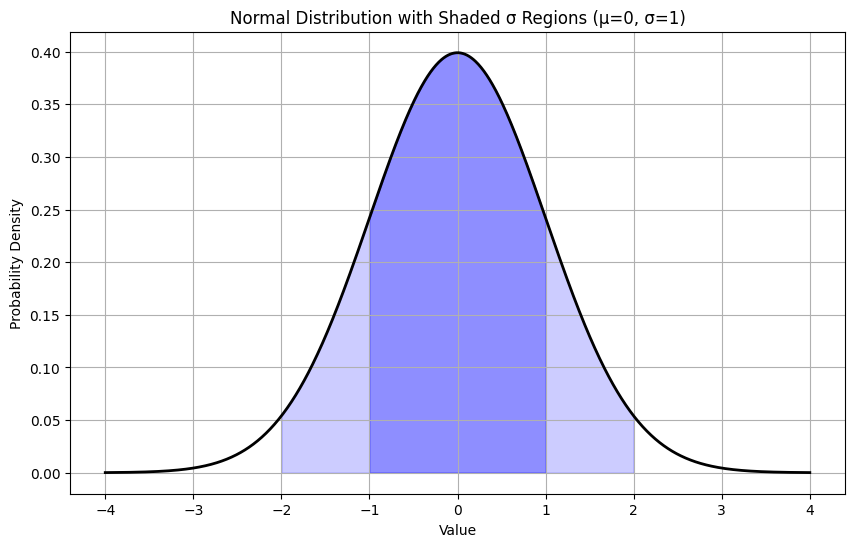

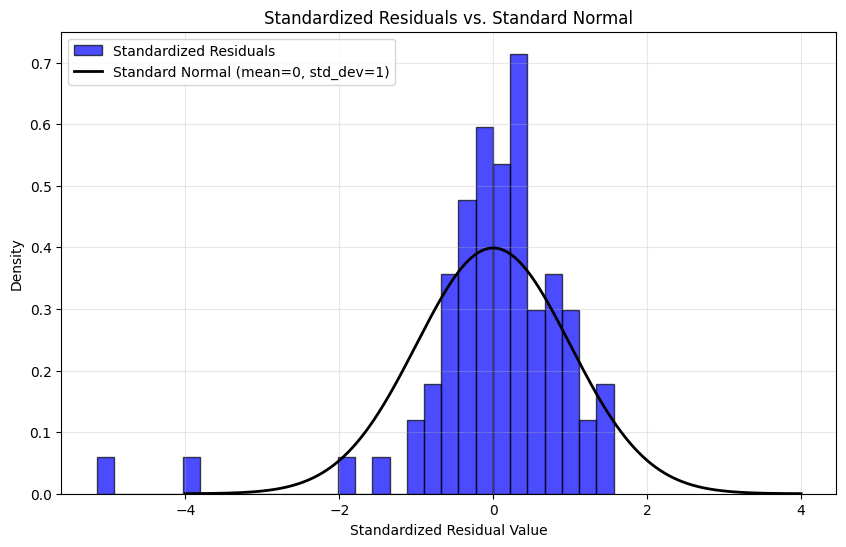

K-S statistic: 0.1450
P-value: 0.0770
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [12]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 154368_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-154368')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.001  # Assuming a standard deviation for the error
num_params = 14  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

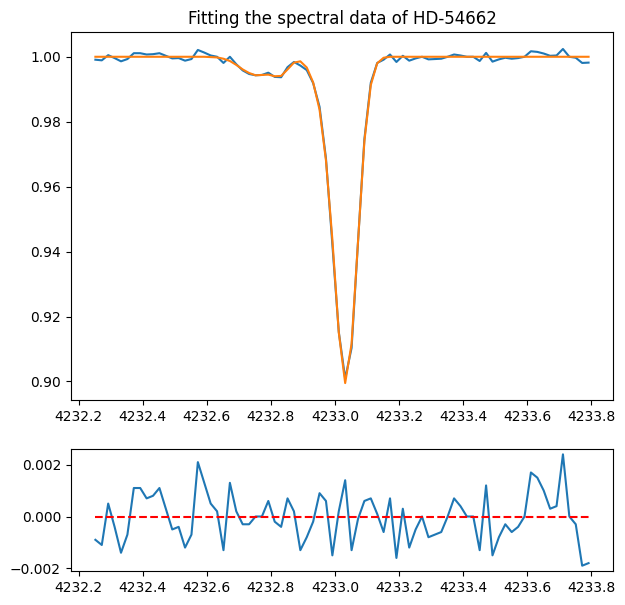

number of parameters: 14
Chi-squared: 135.81632653061257
Reduced Chi-squared: 2.1221301020408214
Log-likelihood: 427.0402
AIC:  -826.0803770651141
BIC:  -793.0864534914599


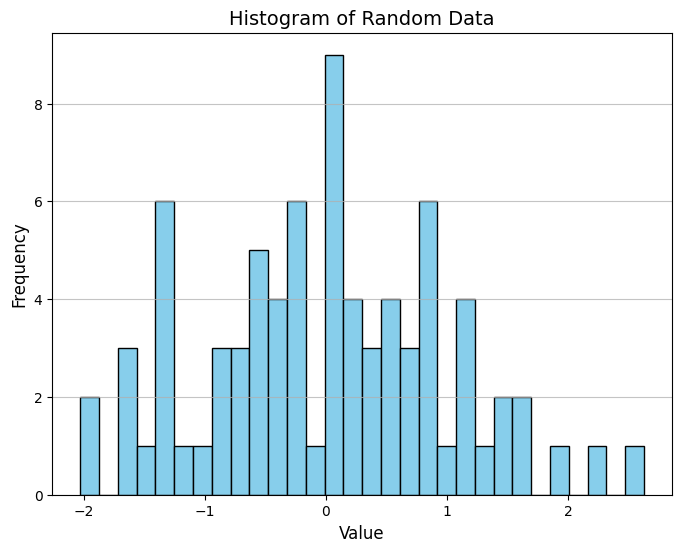

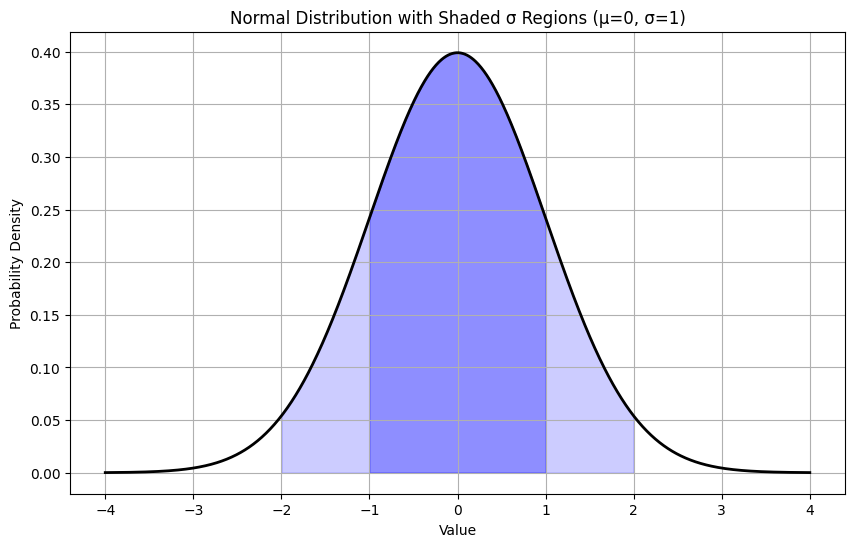

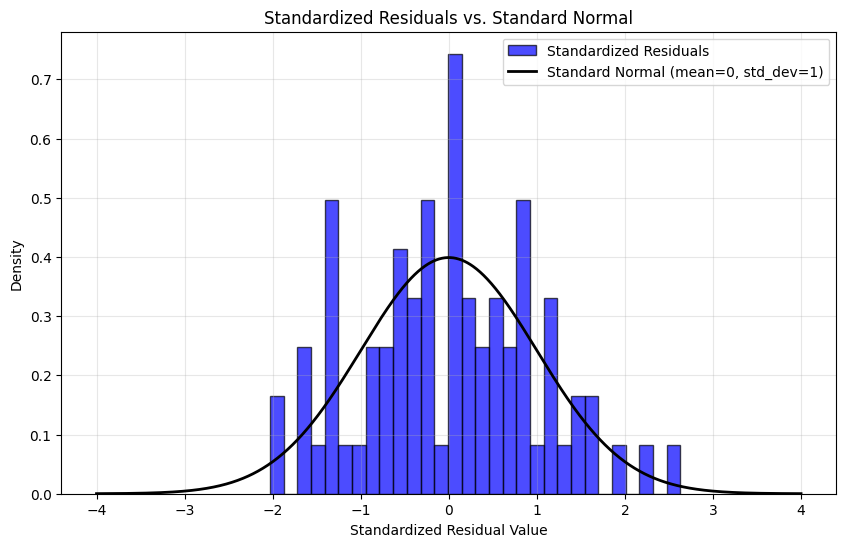

K-S statistic: 0.0525
P-value: 0.9750
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [13]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 54662_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-54662')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0007  # Assuming a standard deviation for the error
num_params = 14  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

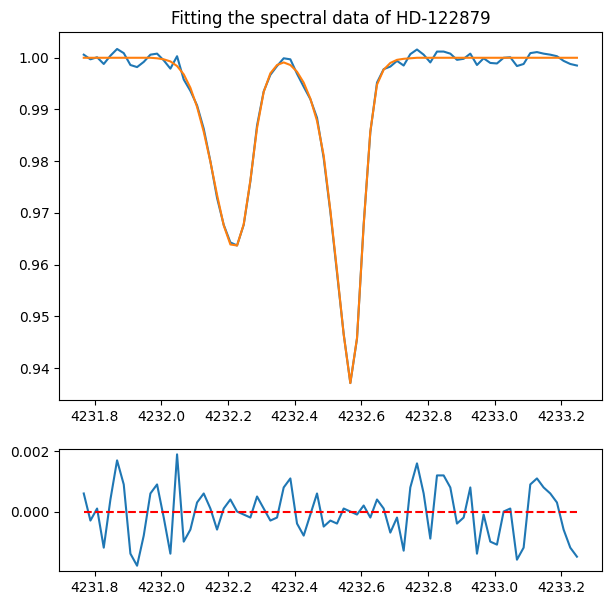

number of parameters: 17
Chi-squared: 91.12888888888676
Reduced Chi-squared: 1.571187739463565
Log-likelihood: 425.1730
AIC:  -816.3459338455
BIC:  -776.9486359153827


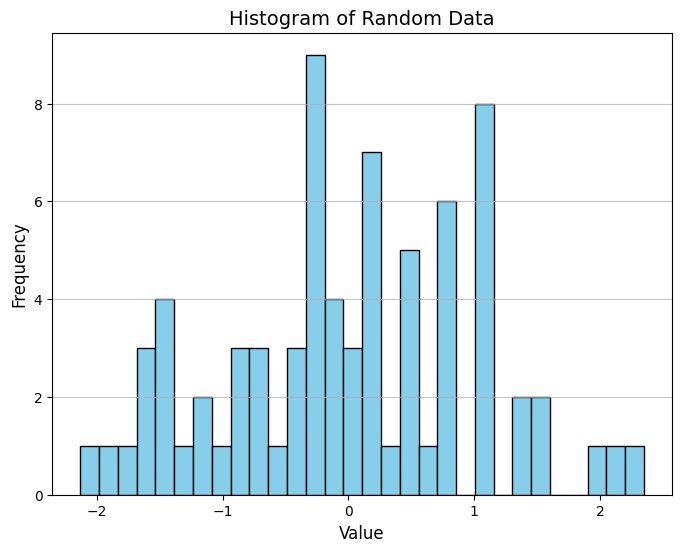

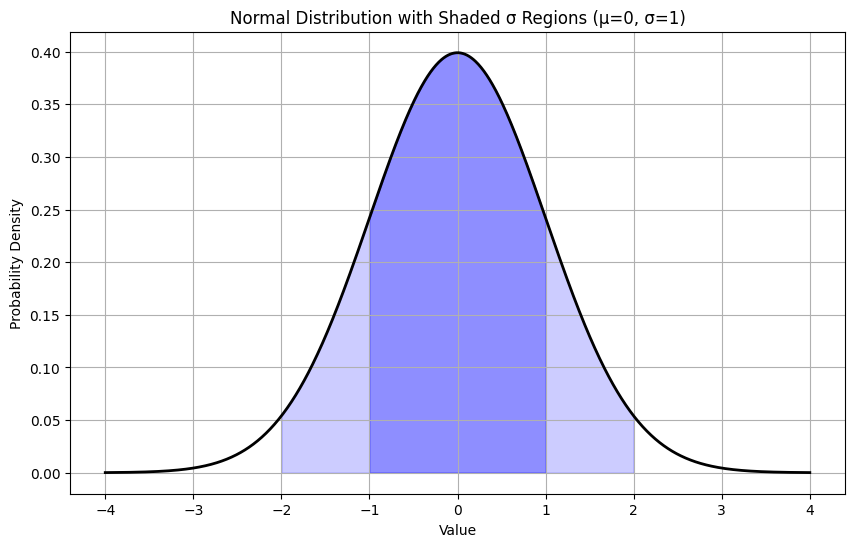

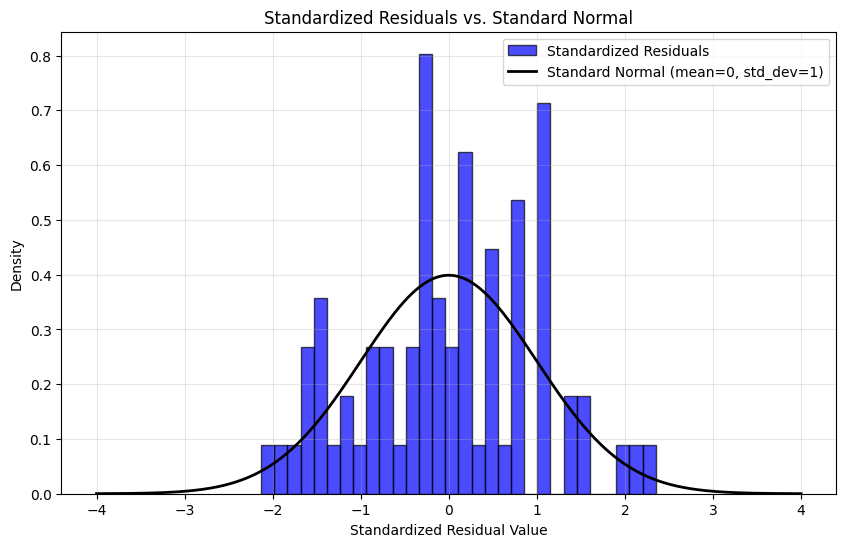

K-S statistic: 0.0632
P-value: 0.9071
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [14]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 122879_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-122879')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00075  # Assuming a standard deviation for the error
num_params = 17  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

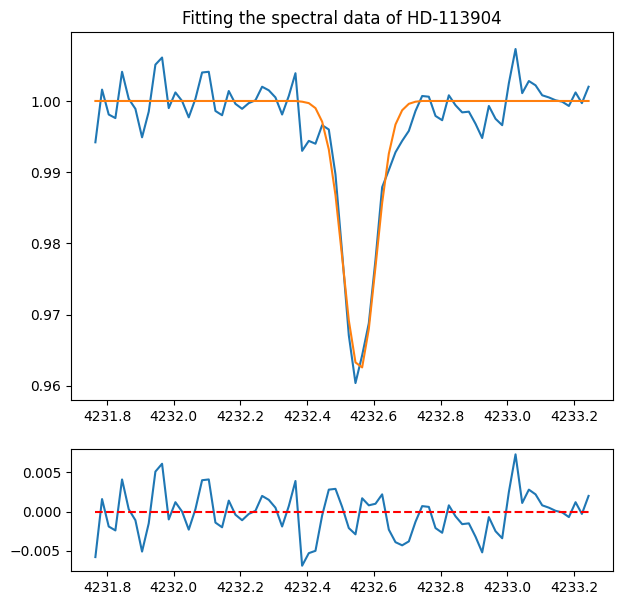

number of parameters: 3
Chi-squared: 64.46222222222262
Reduced Chi-squared: 0.8953086419753142
Log-likelihood: 334.5342
AIC:  -663.0684463441806
BIC:  -656.1159820035717


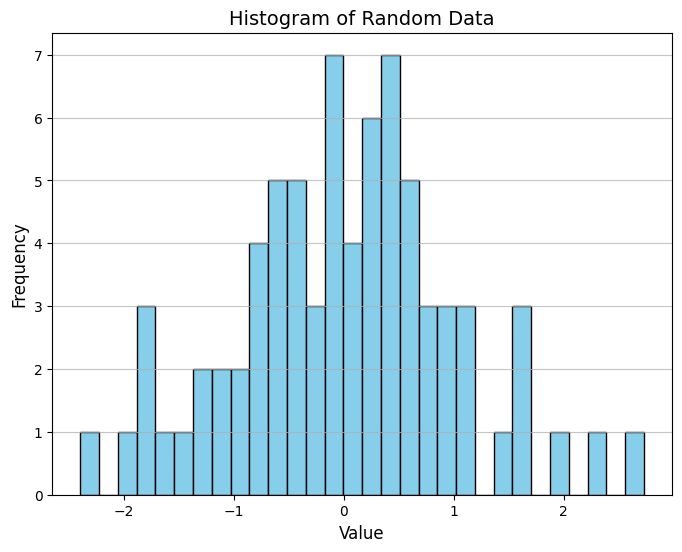

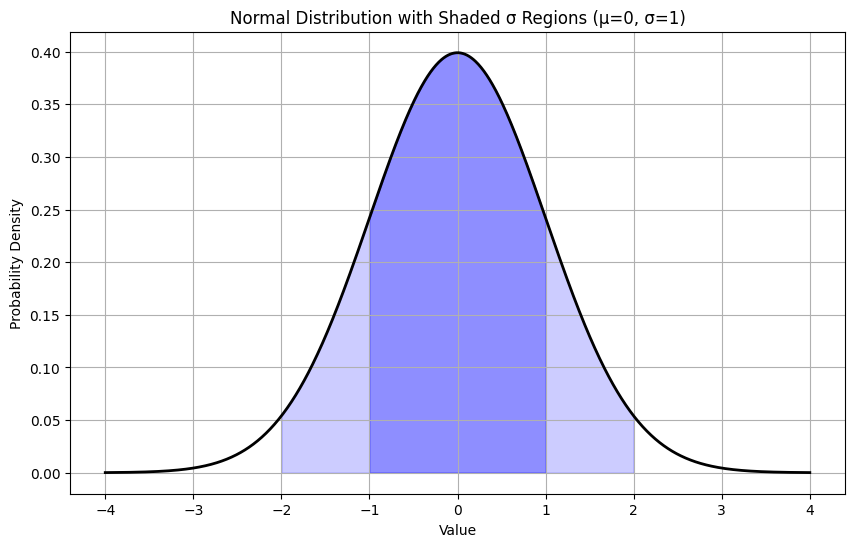

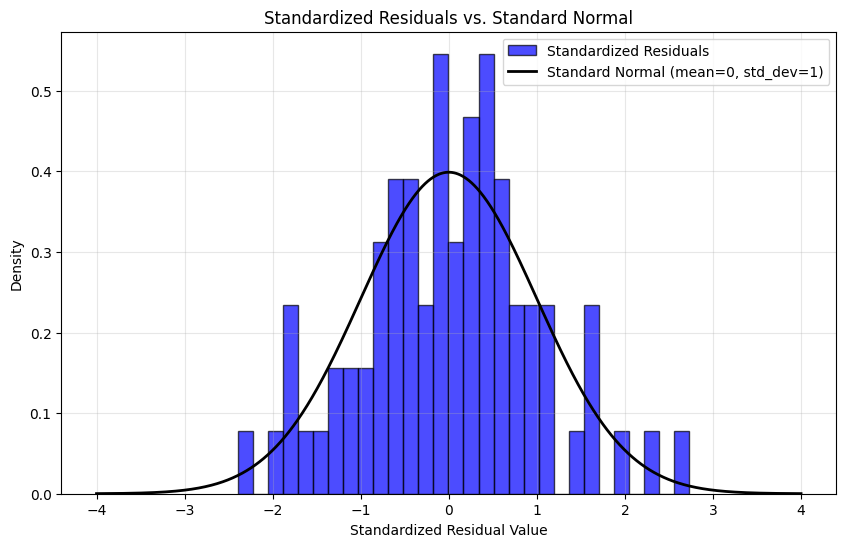

K-S statistic: 0.0455
P-value: 0.9959
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [15]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 113904_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-113904')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.003  # Assuming a standard deviation for the error
num_params = 3  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

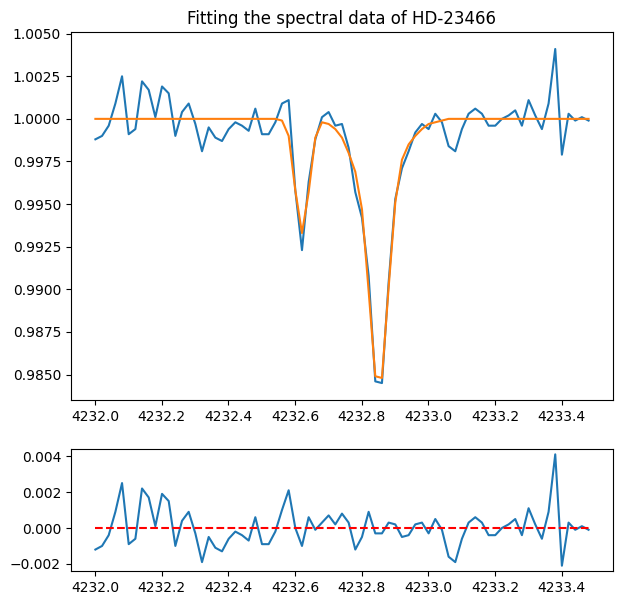

number of parameters: 15
Chi-squared: 55.38194444444413
Reduced Chi-squared: 0.9230324074074022
Log-likelihood: 407.7962
AIC:  -785.5923339030825
BIC:  -750.8300122000378


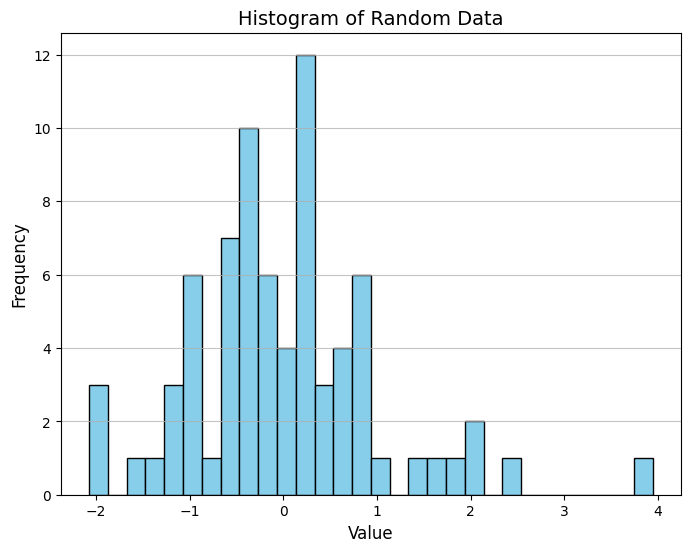

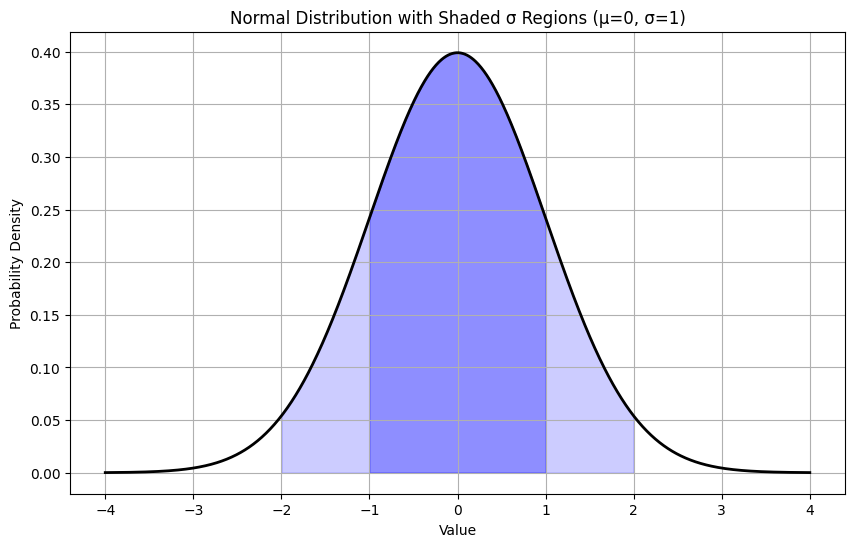

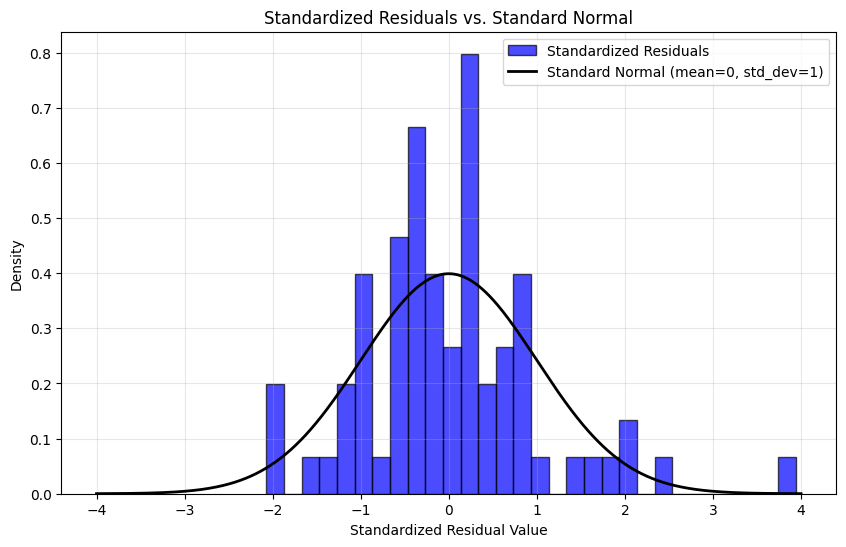

K-S statistic: 0.1189
P-value: 0.2212
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [16]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 23466_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-23466')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0012  # Assuming a standard deviation for the error
num_params = 15  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

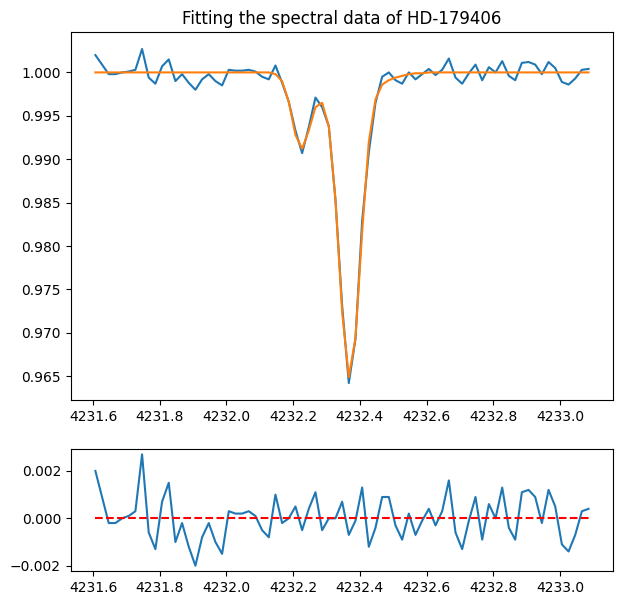

number of parameters: 12
Chi-squared: 57.83999999999901
Reduced Chi-squared: 0.9180952380952223
Log-likelihood: 420.2413
AIC:  -816.4825118666207
BIC:  -788.672654504185


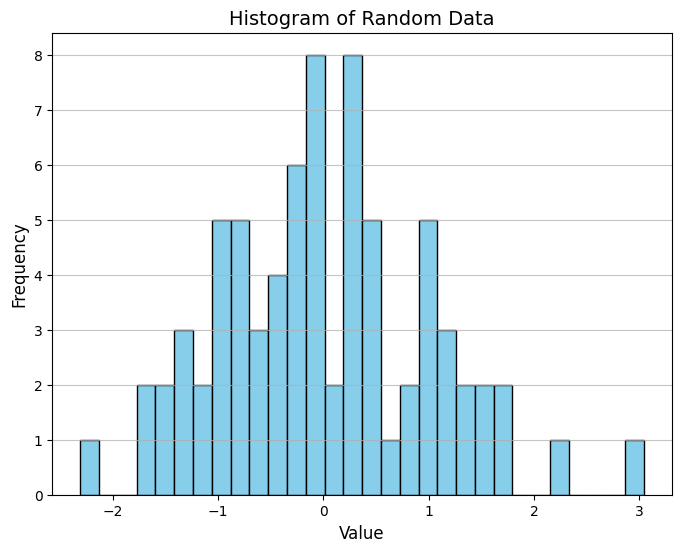

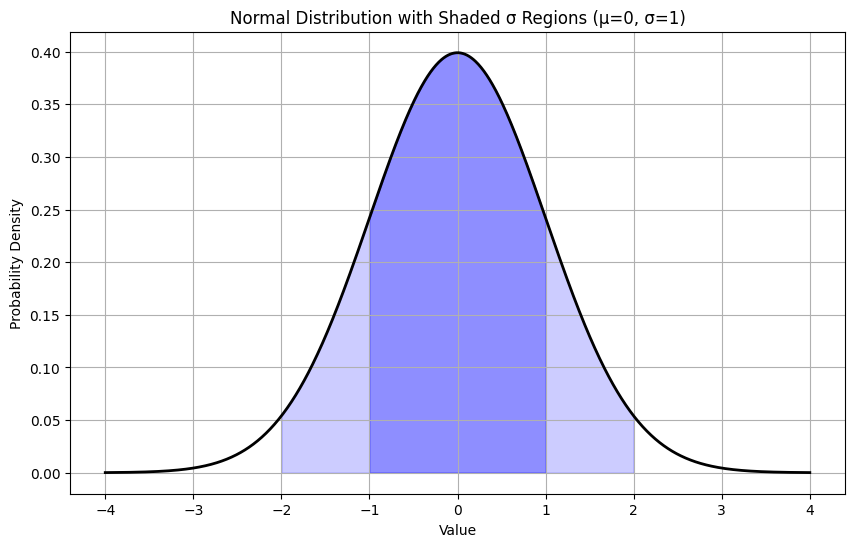

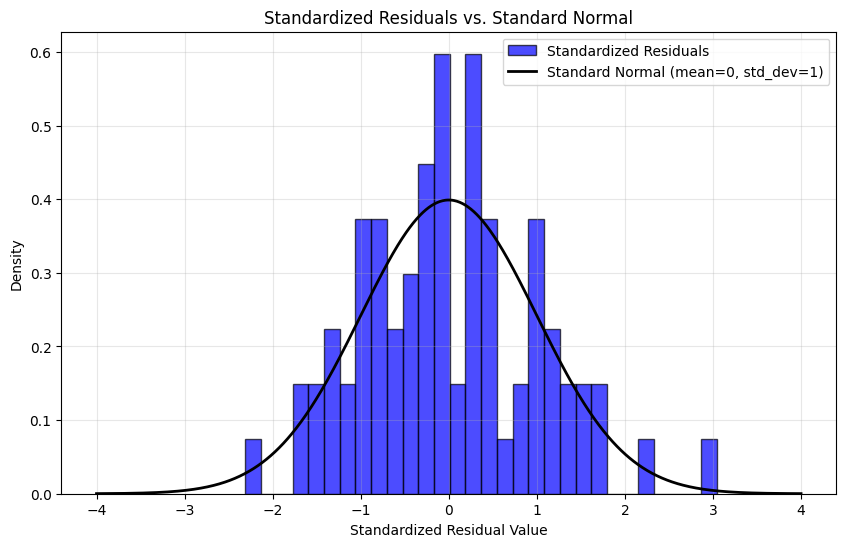

K-S statistic: 0.0588
P-value: 0.9442
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [17]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 179406_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-179406')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.001  # Assuming a standard deviation for the error
num_params = 12  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

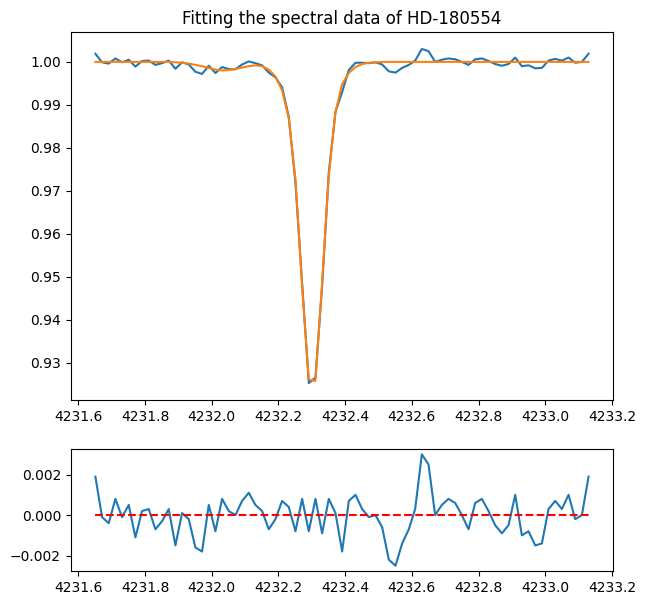

number of parameters: 8
Chi-squared: 150.77551020407628
Reduced Chi-squared: 2.2503807493145715
Log-likelihood: 400.5241
AIC:  -785.0482432533531
BIC:  -766.5083383450626


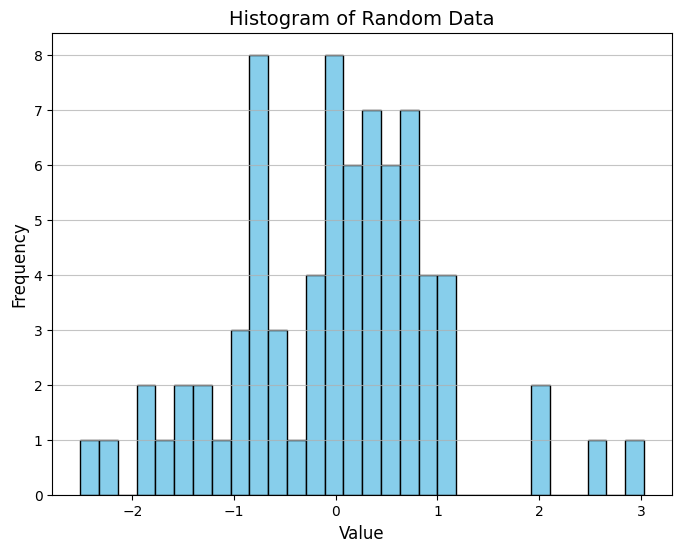

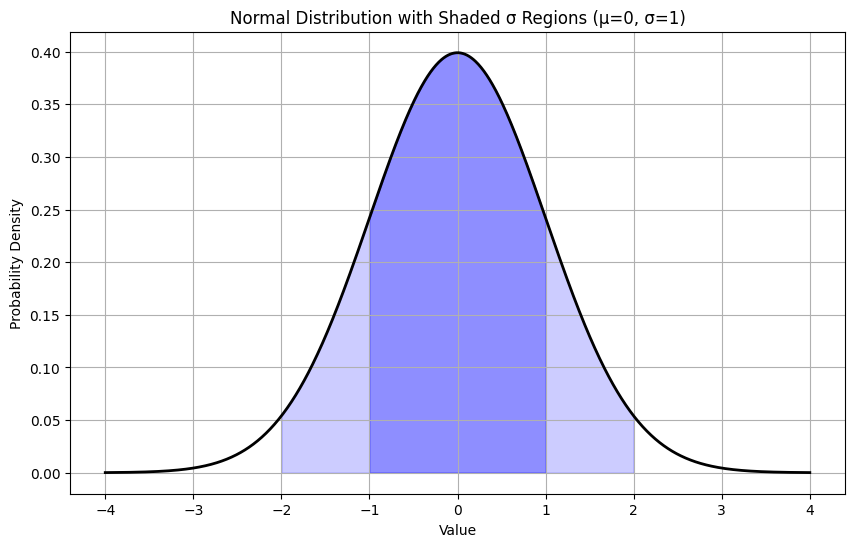

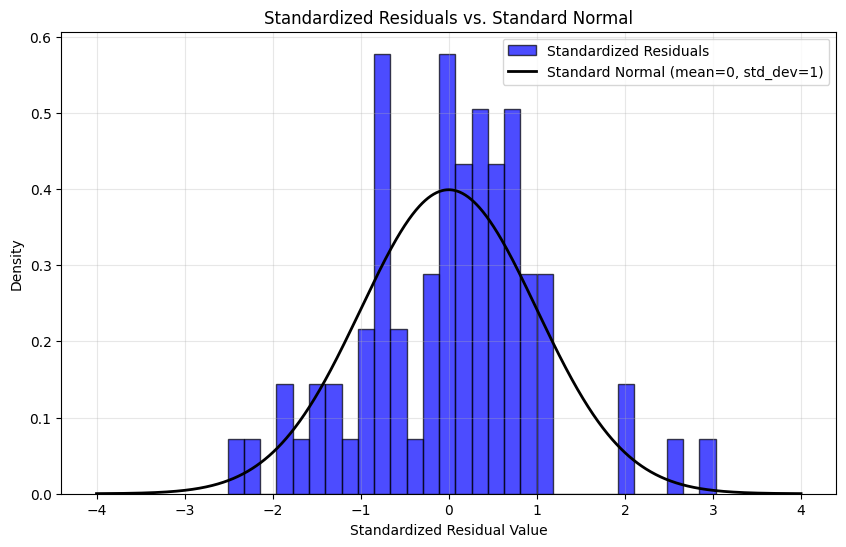

K-S statistic: 0.1011
P-value: 0.4005
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [18]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 180554_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-180554')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0007  # Assuming a standard deviation for the error
num_params = 8  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

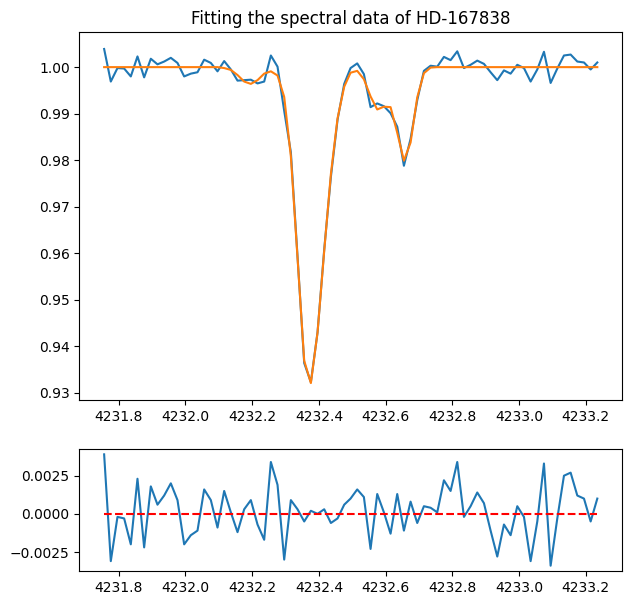

number of parameters: 18
Chi-squared: 115.4437869822481
Reduced Chi-squared: 2.025329596179791
Log-likelihood: 371.7620
AIC:  -707.5240852142481
BIC:  -665.8092991705945


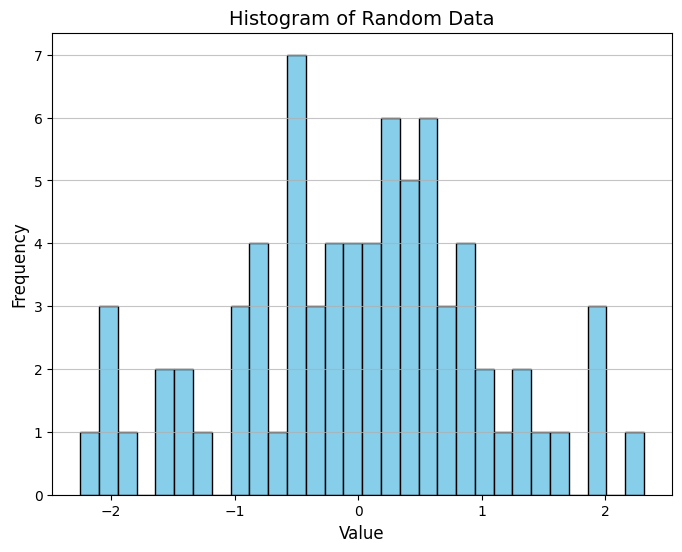

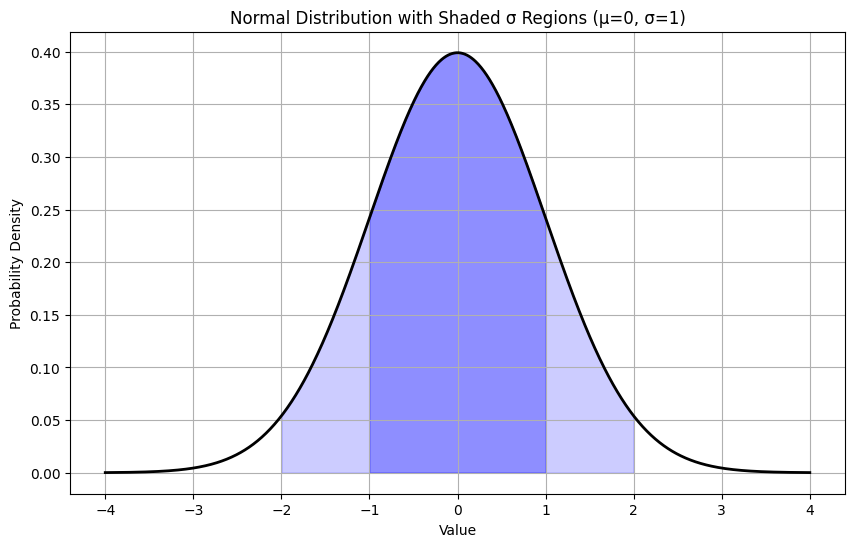

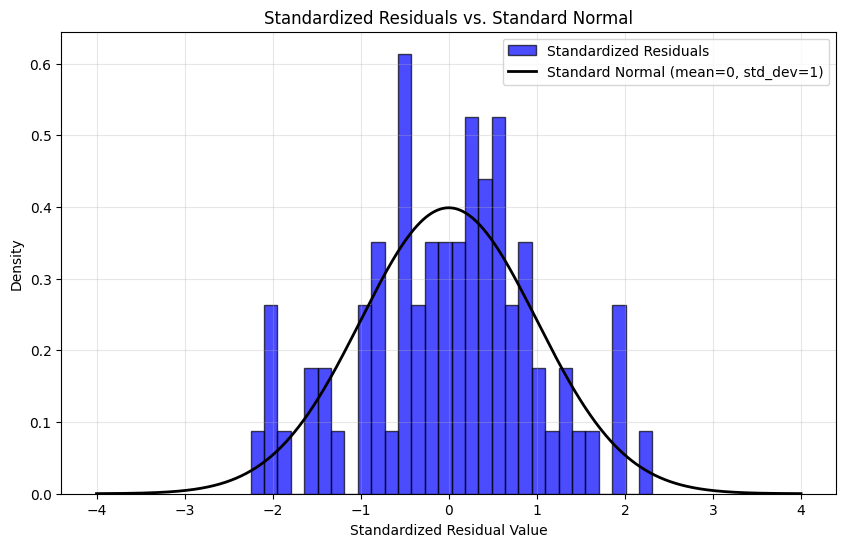

K-S statistic: 0.0484
P-value: 0.9911
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [19]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 167838_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-167838')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0013  # Assuming a standard deviation for the error
num_params = 18  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

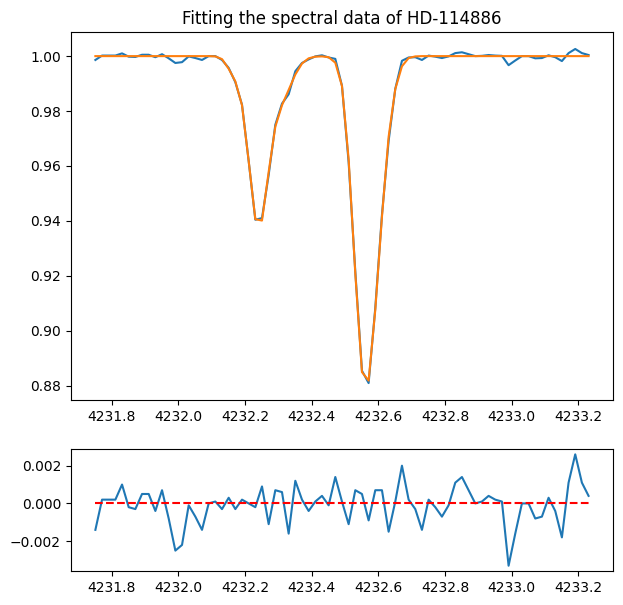

number of parameters: 15
Chi-squared: 184.55039999999863
Reduced Chi-squared: 3.0758399999999773
Log-likelihood: 392.1363
AIC:  -754.2726562534815
BIC:  -719.5103345504368


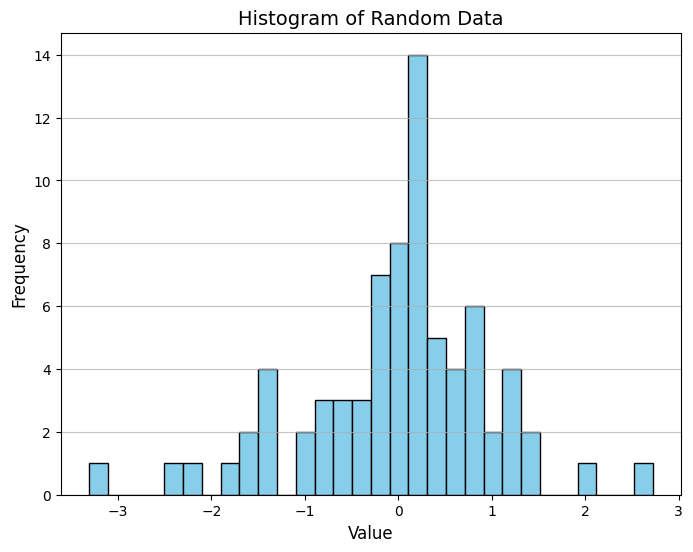

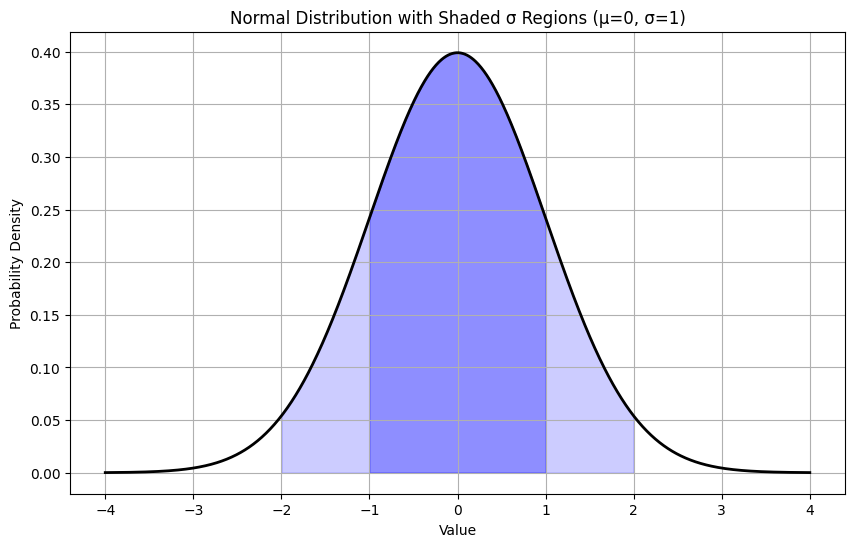

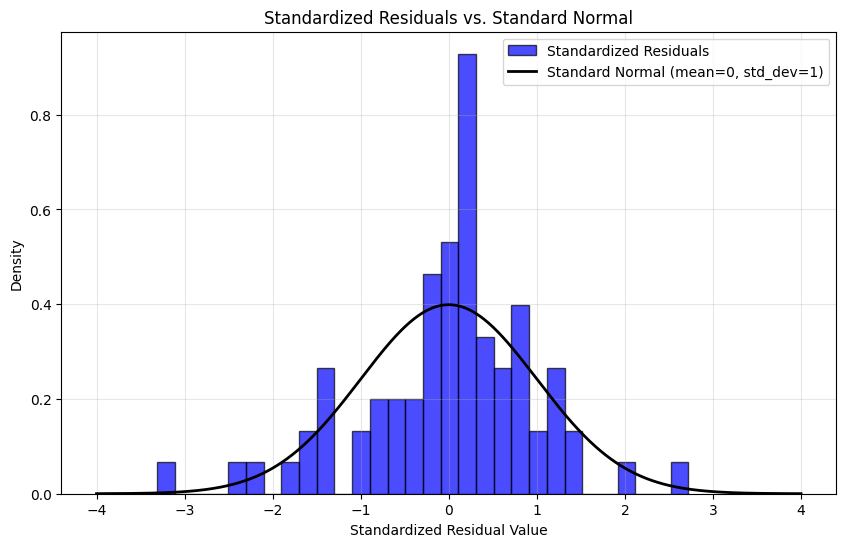

K-S statistic: 0.1251
P-value: 0.1753
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [20]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 114886_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-114886')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.000625  # Assuming a standard deviation for the error
num_params = 15  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

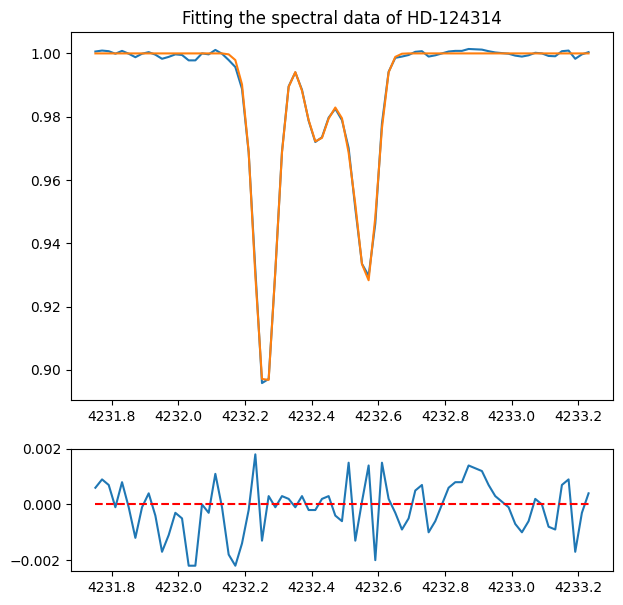

number of parameters: 15
Chi-squared: 172.08636836628236
Reduced Chi-squared: 2.8681061394380394
Log-likelihood: 398.9708
AIC:  -767.9415136417873
BIC:  -733.1791919387426


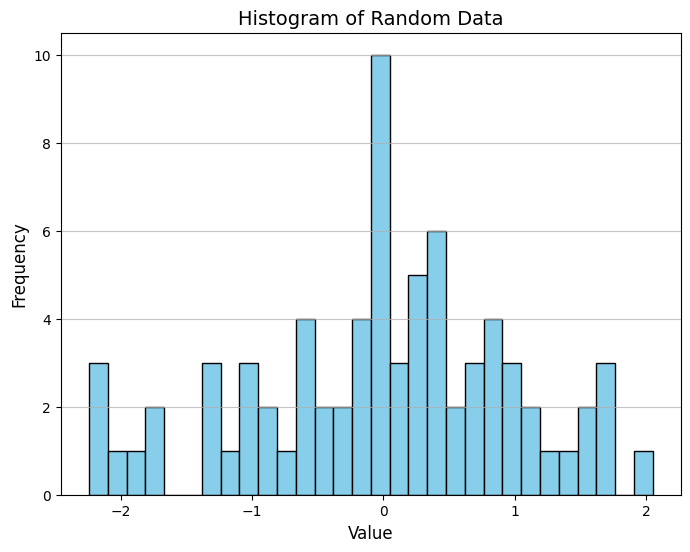

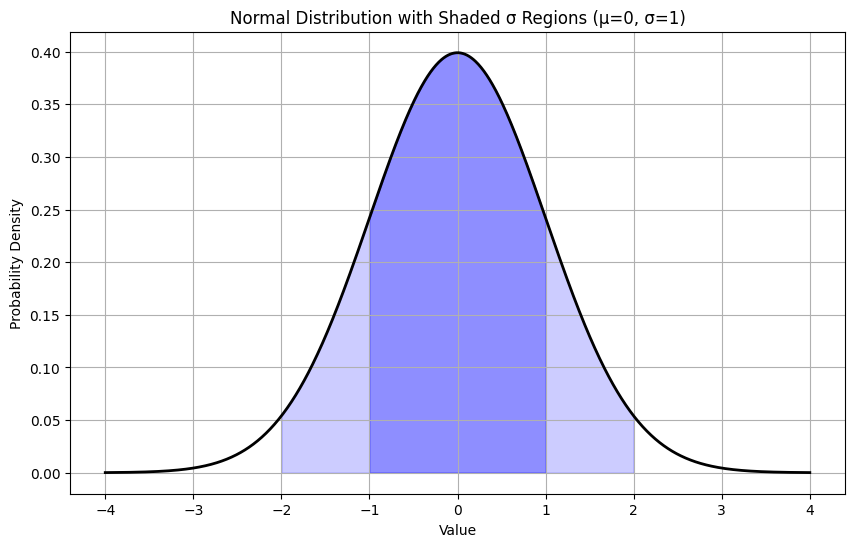

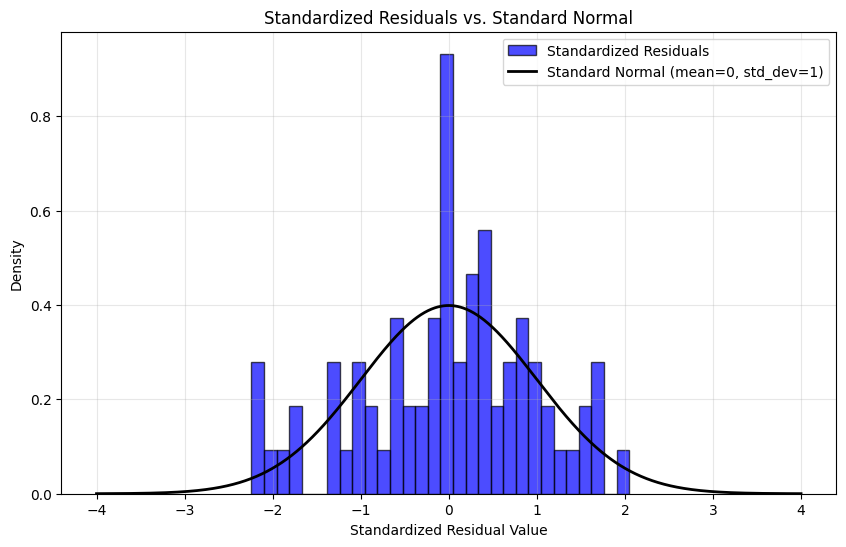

K-S statistic: 0.0862
P-value: 0.6018
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [21]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 124314_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-124314')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00062  # Assuming a standard deviation for the error
num_params = 15  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

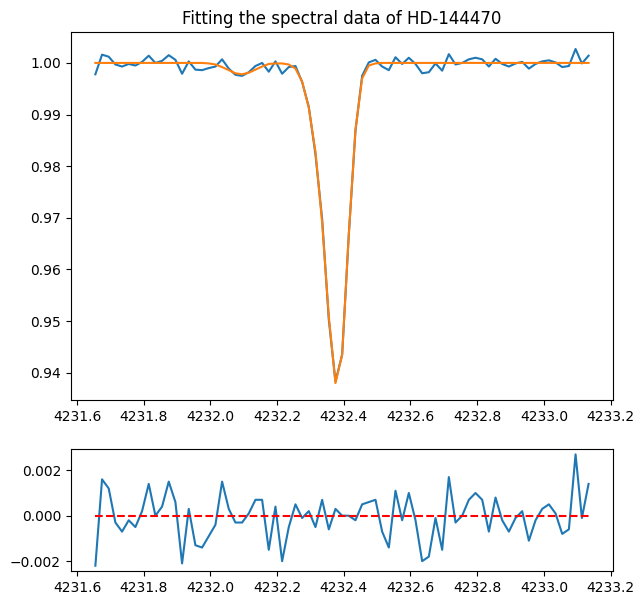

number of parameters: 8
Chi-squared: 96.87335877595225
Reduced Chi-squared: 1.44587102650675
Log-likelihood: 413.3560
AIC:  -810.711950834412
BIC:  -792.1720459261215


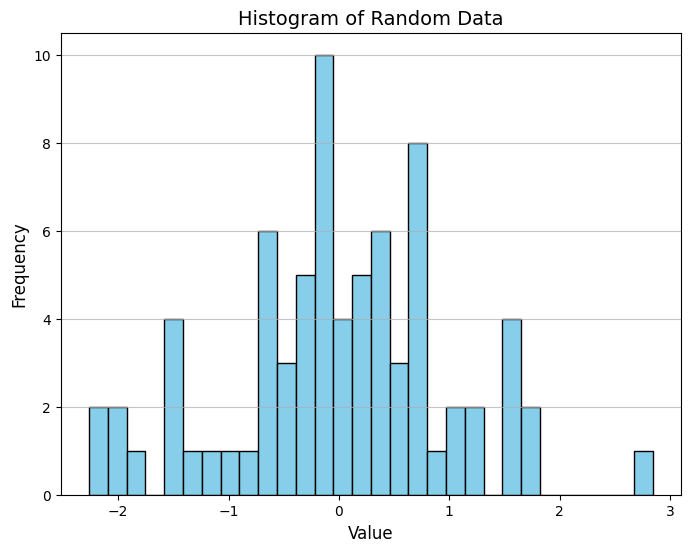

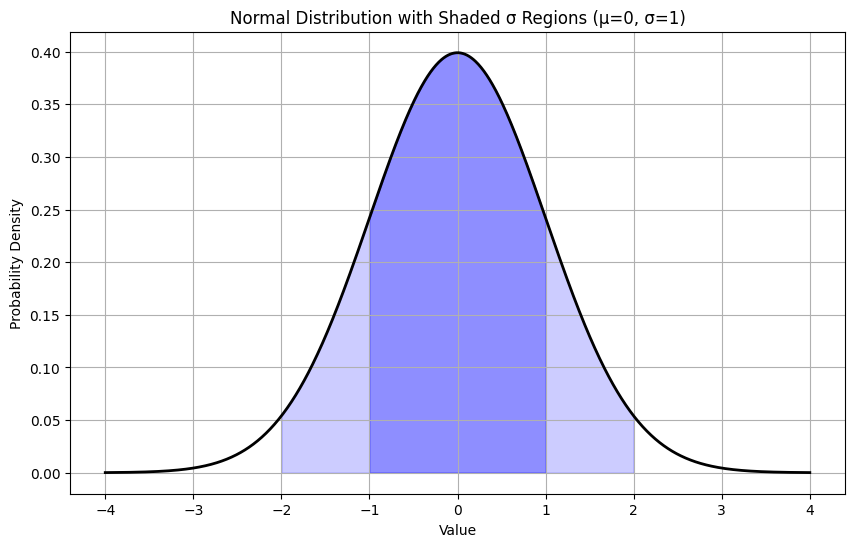

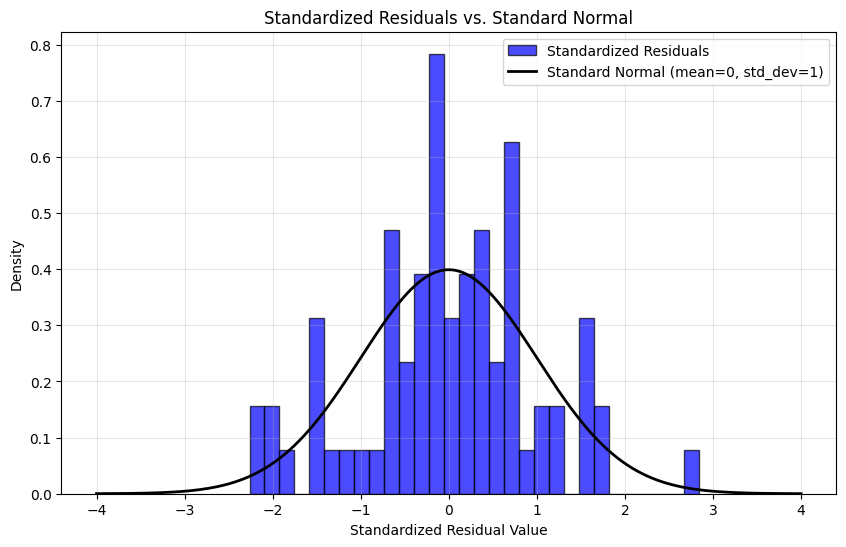

K-S statistic: 0.0818
P-value: 0.6668
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [22]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 144470_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-144470')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.000845  # Assuming a standard deviation for the error
num_params = 8  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

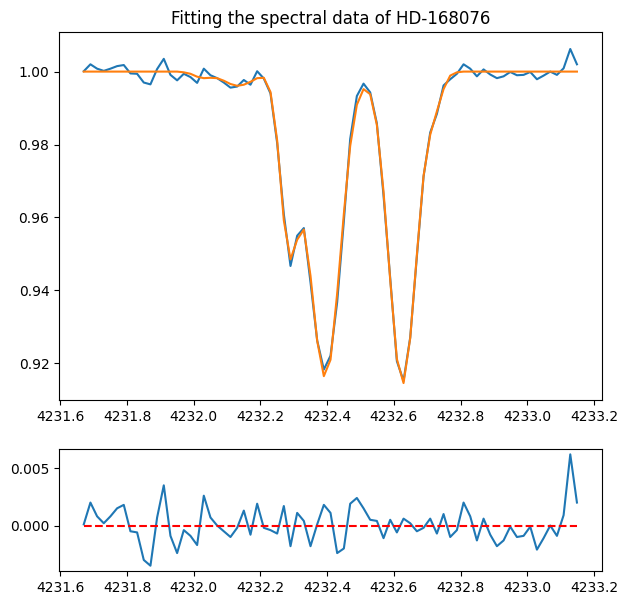

number of parameters: 17
Chi-squared: 104.91124260354965
Reduced Chi-squared: 1.808814527647408
Log-likelihood: 377.0283
AIC:  -720.0566295929465
BIC:  -680.6593316628292


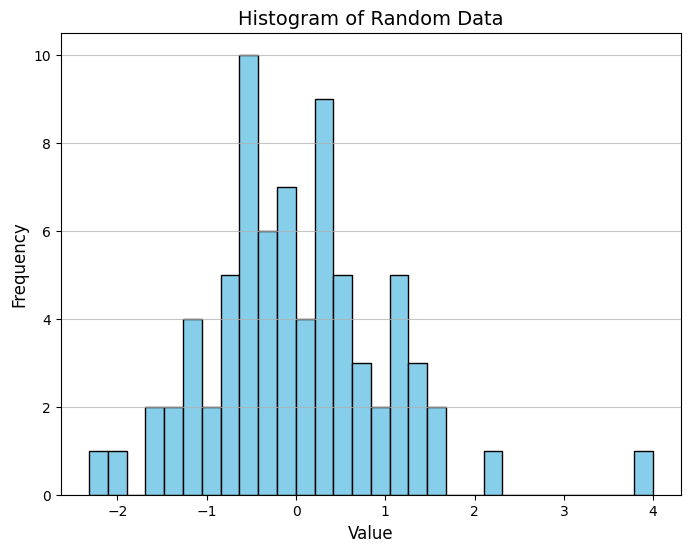

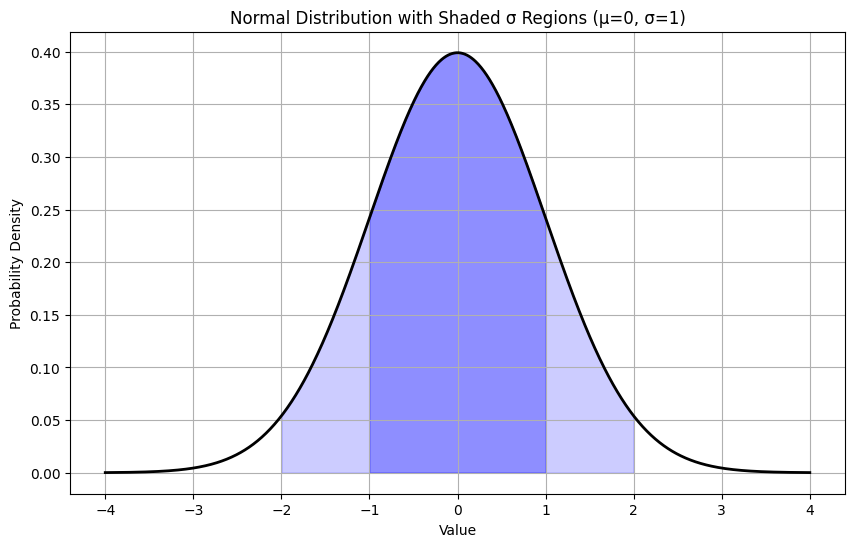

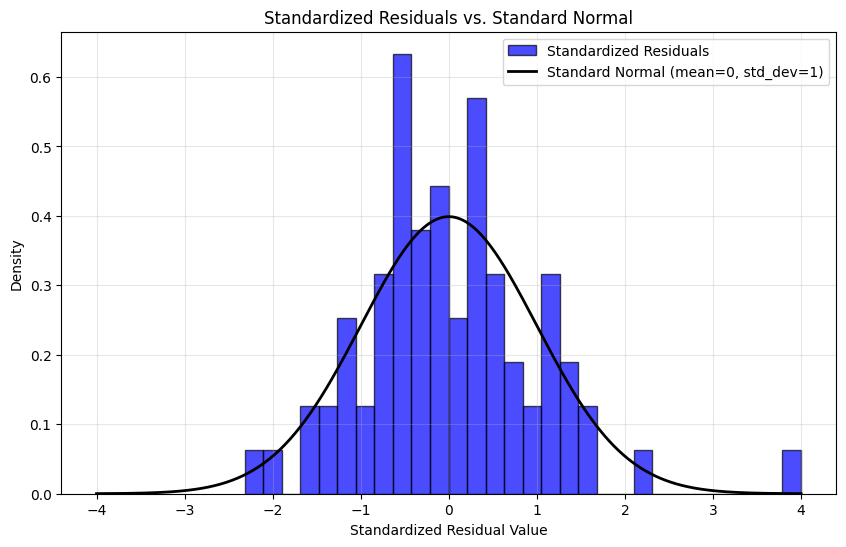

K-S statistic: 0.0648
P-value: 0.8903
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [23]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 168076_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-168076')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.0013  # Assuming a standard deviation for the error
num_params = 17  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

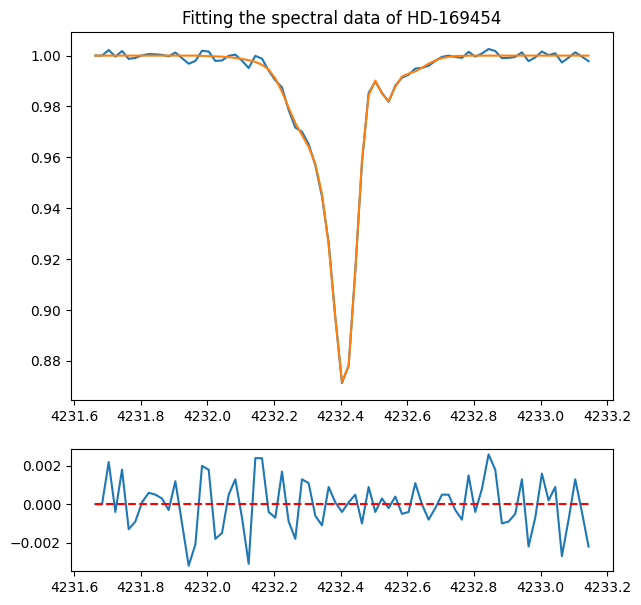

number of parameters: 18
Chi-squared: 79.4688000000003
Reduced Chi-squared: 1.3941894736842158
Log-likelihood: 392.6911
AIC:  -749.3821791694879
BIC:  -707.6673931258343


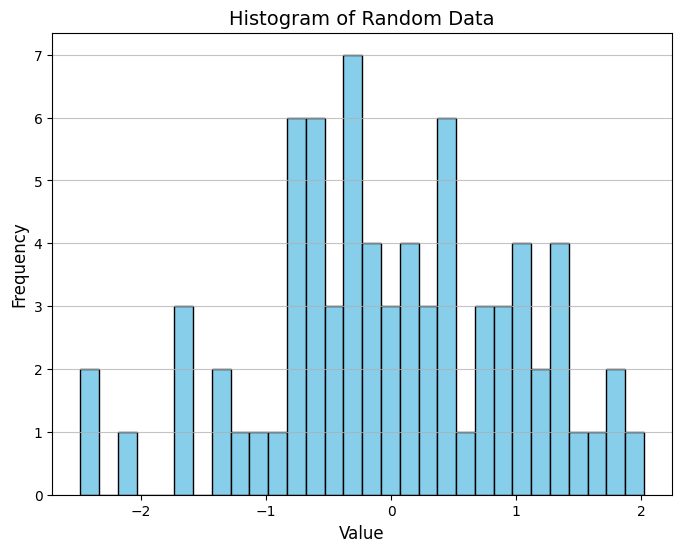

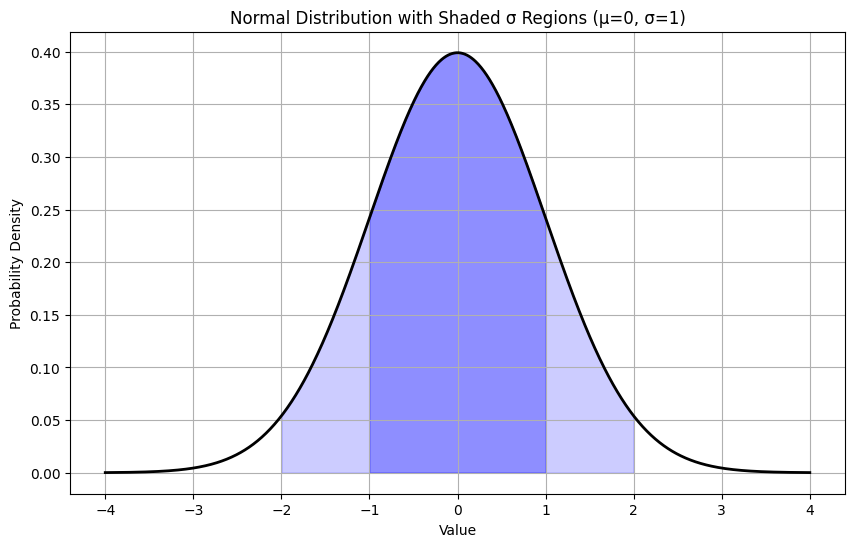

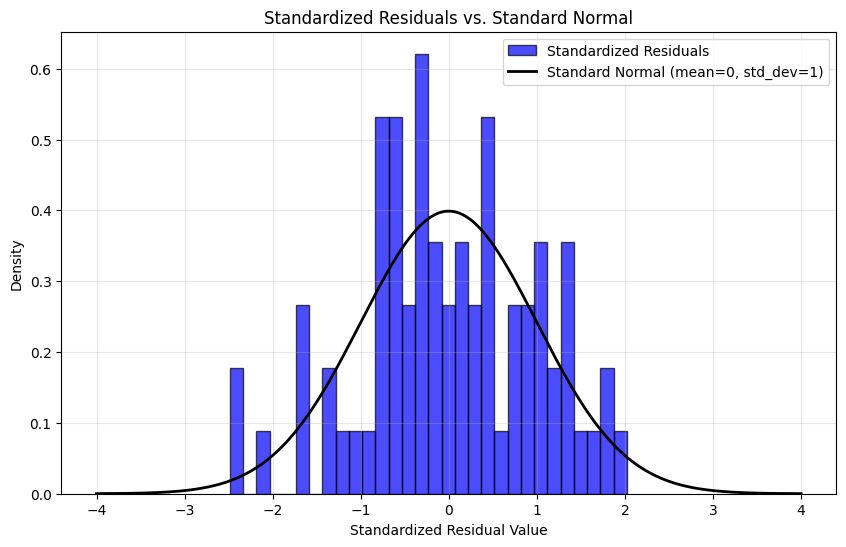

K-S statistic: 0.0722
P-value: 0.8028
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [24]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 169454_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-169454')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00125  # Assuming a standard deviation for the error
num_params = 18  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

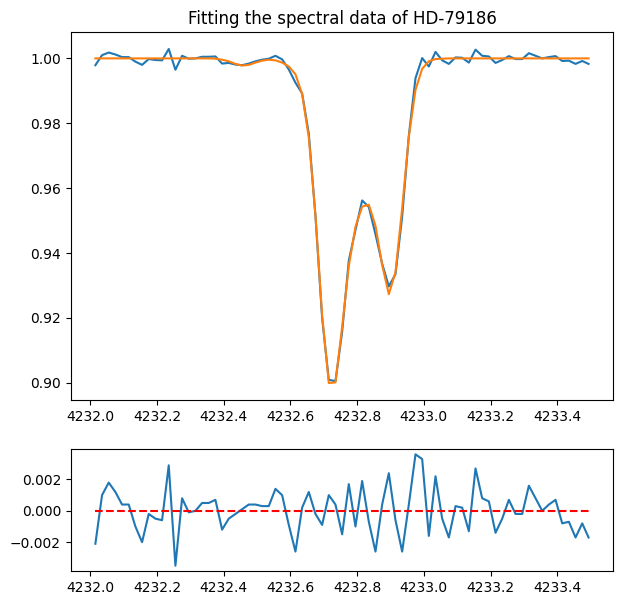

number of parameters: 11
Chi-squared: 361.55202821868687
Reduced Chi-squared: 5.649250440916982
Log-likelihood: 303.0379
AIC:  -584.0758025874168
BIC:  -558.5834333385174


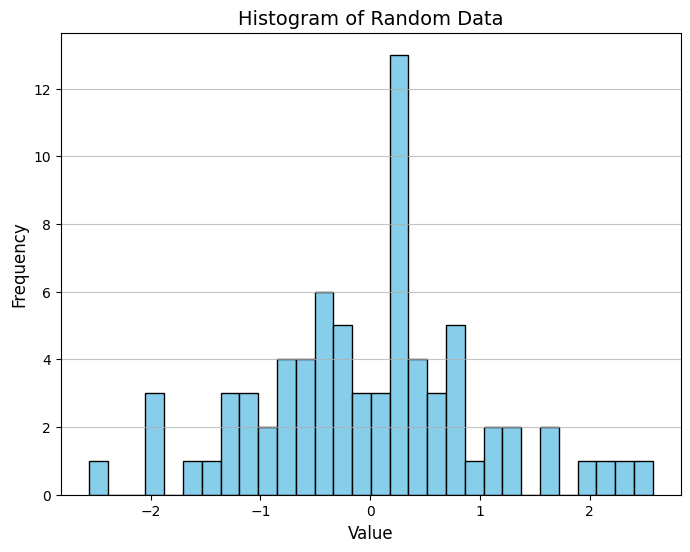

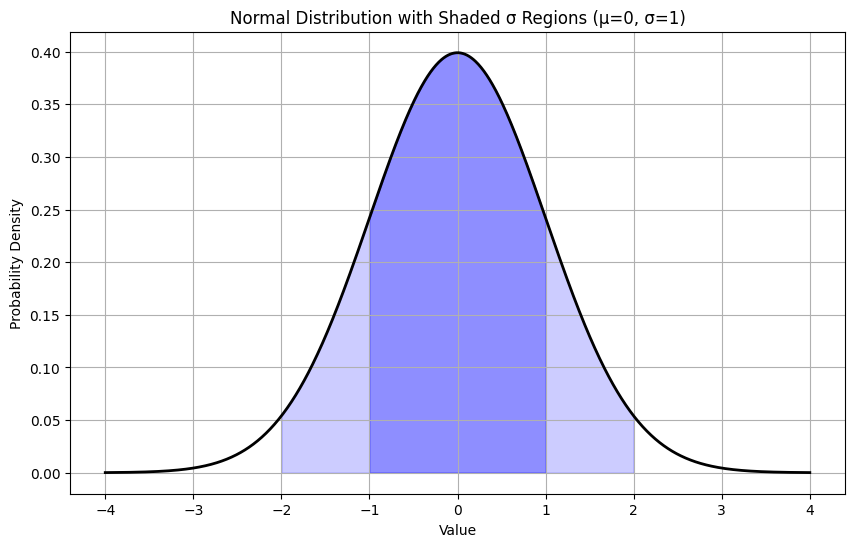

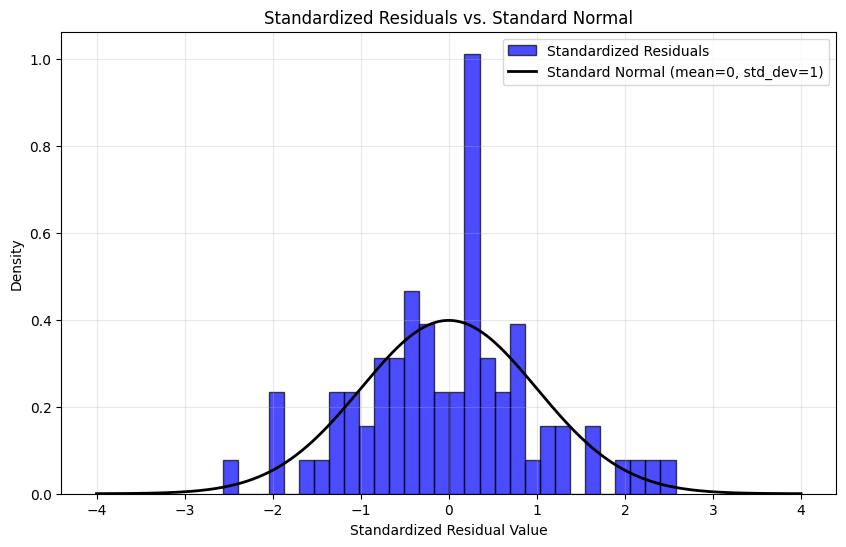

K-S statistic: 0.0779
P-value: 0.7227
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [34]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 79186_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-79186')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00063  # Assuming a standard deviation for the error
num_params = 11  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

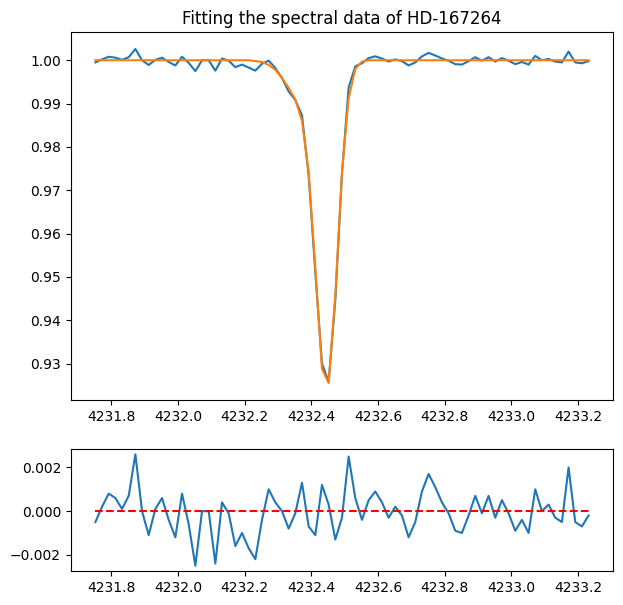

number of parameters: 9
Chi-squared: 82.28696959185811
Reduced Chi-squared: 1.2467722665433048
Log-likelihood: 413.4606
AIC:  -808.9211461999869
BIC:  -788.0637531781601


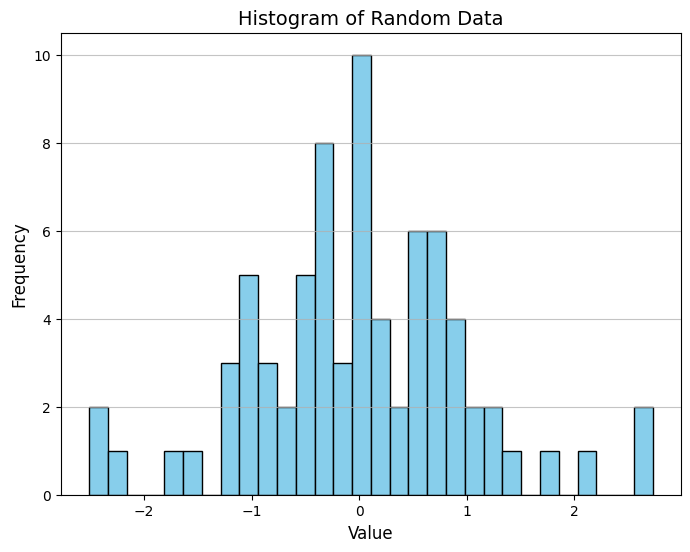

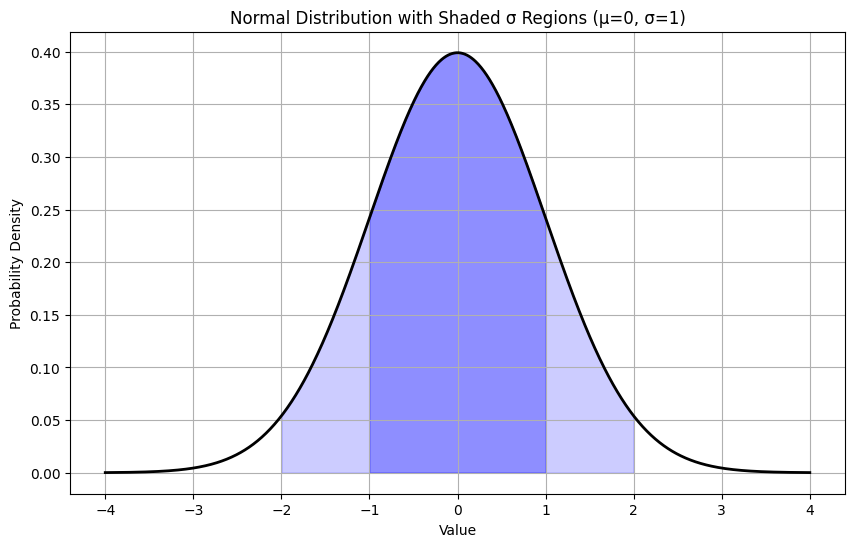

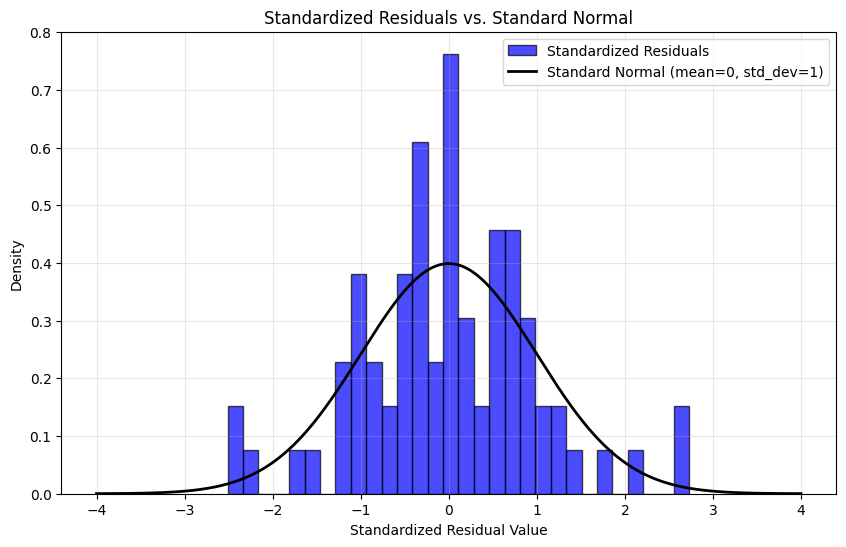

K-S statistic: 0.0711
P-value: 0.8162
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [38]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 167264_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-167264')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00093  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

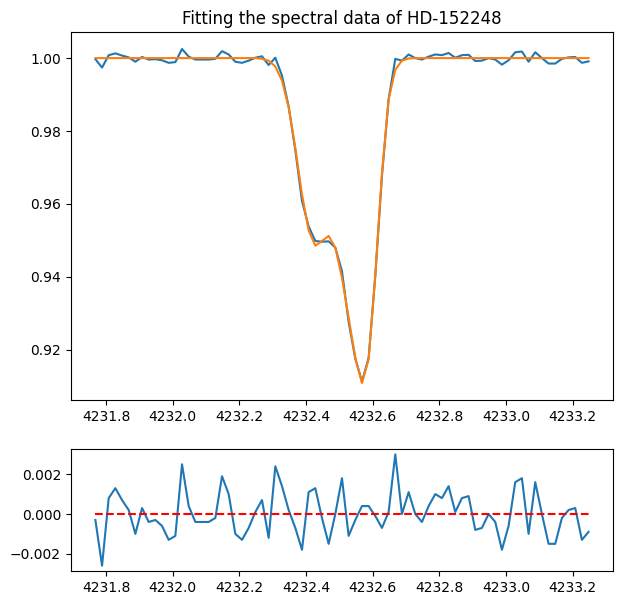

number of parameters: 9
Chi-squared: 91.85797367615395
Reduced Chi-squared: 1.3917874799417265
Log-likelihood: 403.9860
AIC:  -789.9720885684909
BIC:  -769.114695546664


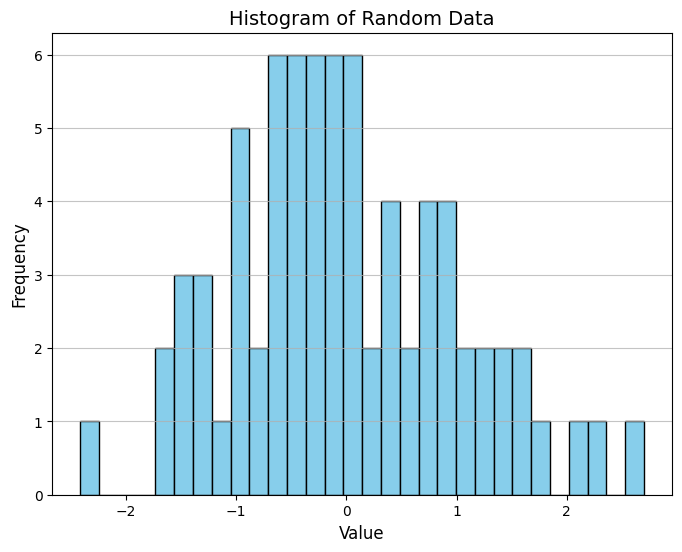

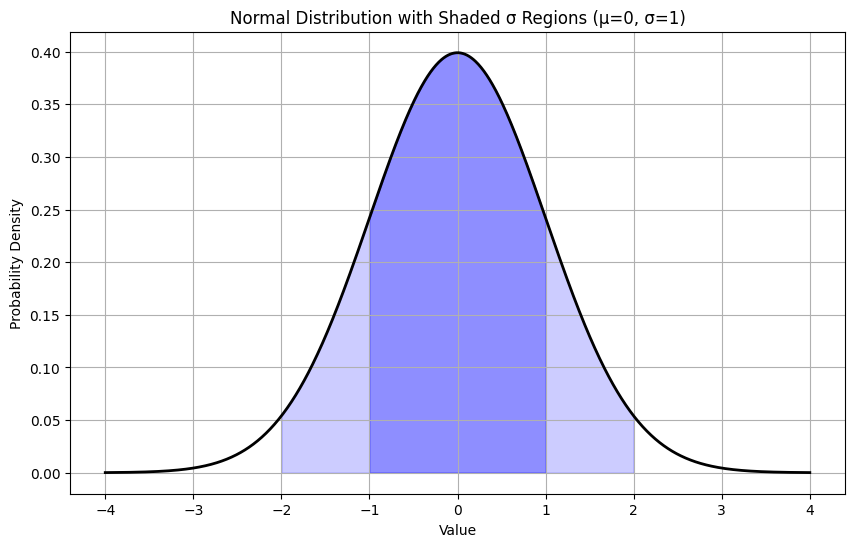

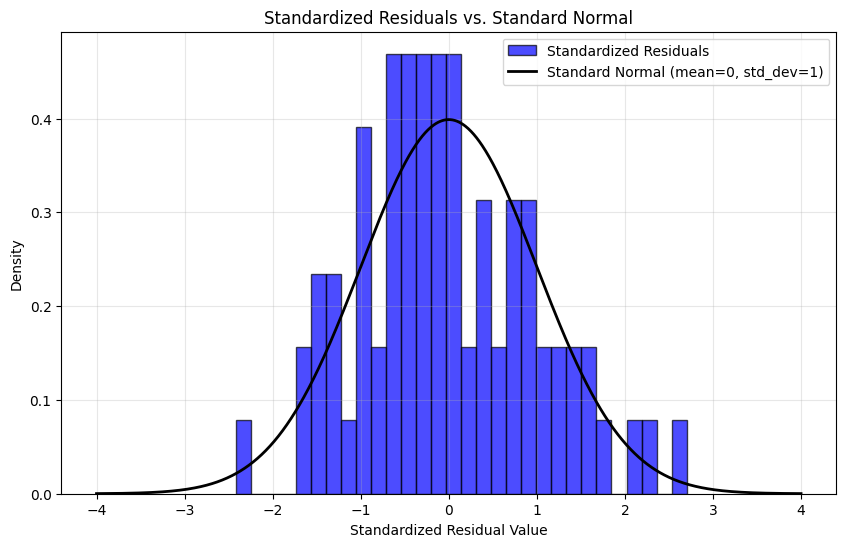

K-S statistic: 0.0792
P-value: 0.7047
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [15]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 152248_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-152248')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
# Show the plot
plt.show()

### chisquared calculator.

std_dev = 0.00099  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")